# Homework 6 — Problem 2  
## Reliability Analysis of a Two-Storey Shear-Type Building

This notebook solves **Problem 2** of Homework 6. The structure is a two-storey shear-type building with uncertain storey stiffnesses and horizontal loads.

The random variables are:

$$
K_1,\;K_2,\;P_1,\;P_2
$$

where:

- $(K_1)$ and $(K_2)$ are storey stiffness parameters obtained from monitoring data,
- $(P_1)$ and $(P_2)$ are horizontal load variables obtained from load data.

The reliability analysis is performed in two cases:

1. **Case 1:** $(K_1)$ and $(K_2)$ are random, while $(P_1)$ and $(P_2)$ are fixed at nominal values.
2. **Case 2:** $(K_1)$, $(K_2)$, $(P_1)$, and $(P_2)$ are all treated as random variables.

The main objectives are to:

- fit suitable probability distributions to the monitoring data,
- formulate the roof-displacement limit-state function,
- compute the design point using the HLRF algorithm,
- estimate the reliability index and probability of failure using FORM,
- validate the FORM results using Monte Carlo and importance sampling methods.

<h1>Import Libraries</h1>

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.linalg import cholesky
from IPython.display import Image, display, Markdown
import warnings
warnings.filterwarnings('ignore')

<h1>Plot Style</h1>

In [3]:

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

<h1>Load datas</h1>

In [5]:
datak = pd.read_csv("Data_K.csv", header=None, names=["K1", "K2"])
datap = pd.read_csv("Data_P.csv", header=None, names=["P1", "P2"])

# Use a manageable random subset for speed (10 000 samples)
RNG_SEED = 42
N_SAMPLE  = 10_000

rng = np.random.default_rng(RNG_SEED)
idx_K = rng.choice(len(datak), N_SAMPLE, replace=False)
idx_P = rng.choice(len(datap), N_SAMPLE, replace=False)
 
K1 = datak['K1'].values[idx_K]   # [N/mm]
K2 = datak['K2'].values[idx_K]   # [N/mm]
P1 = datap['P1'].values[idx_P]   # [N]
P2 = datap['P2'].values[idx_P]   # [N]
 
print(f"\n  Samples loaded — K data: {len(K1):,}  |  P data: {len(P1):,}")


  Samples loaded — K data: 10,000  |  P data: 10,000


In [6]:
datak.head()

,K1,K2
0,7383.162976,4127.993727
1,7849.145201,4403.201587
2,6377.833671,4204.903017
3,7499.820920,4343.025723
4,7304.469111,4175.179300


In [7]:
datap.head()

,P1,P2
0,51655.548415,170692.848700
1,85179.728279,364145.921851
2,72558.438833,297674.099852
3,109899.839598,440720.625533
4,80433.123936,304196.906025


<h1>Fit bivariate normal distribution for stiffness</h1>

The stiffness variables $(K_1)$ and $(K_2)$ are modeled using a correlated bivariate normal distribution:

$$
\mathbf{K}
=
\begin{bmatrix}
K_1\\
K_2
\end{bmatrix}
\sim
\mathcal{N}(\boldsymbol{\mu}_K,\boldsymbol{\Sigma}_K).
$$

The mean vector is

$$
\boldsymbol{\mu}_K=
\begin{bmatrix}
\mu_{K_1}\\
\mu_{K_2}
\end{bmatrix},
$$

and the covariance matrix is

$$
\boldsymbol{\Sigma}_K=
\begin{bmatrix}
\sigma_{K_1}^2 & \rho_K\sigma_{K_1}\sigma_{K_2}\\
\rho_K\sigma_{K_1}\sigma_{K_2} & \sigma_{K_2}^2
\end{bmatrix}.
$$

The correlation coefficient is computed as

$$
\rho_K=
\frac{\mathrm{Cov}(K_1,K_2)}
{\sigma_{K_1}\sigma_{K_2}}.
$$

This model captures both the marginal uncertainty of each stiffness variable and their dependence.

In [8]:
mu_K1  = np.mean(K1);   sigma_K1 = np.std(K1, ddof=1)
mu_K2  = np.mean(K2);   sigma_K2 = np.std(K2, ddof=1)
rho_K  = np.corrcoef(K1, K2)[0, 1]
 
mu_K   = np.array([mu_K1, mu_K2])
Sigma_K = np.array([[sigma_K1**2,           rho_K*sigma_K1*sigma_K2],
                    [rho_K*sigma_K1*sigma_K2, sigma_K2**2]])
 
print("\n──────────────────────────────────────────────────────────────────────")
print("  BIVARIATE NORMAL FIT  —  Stiffness (K1, K2)  [N/mm]")
print("──────────────────────────────────────────────────────────────────────")
print(f"  μ_K1  = {mu_K1:>12.4f} N/mm     σ_K1 = {sigma_K1:>10.4f} N/mm")
print(f"  μ_K2  = {mu_K2:>12.4f} N/mm     σ_K2 = {sigma_K2:>10.4f} N/mm")
print(f"  ρ(K1,K2) = {rho_K:.6f}")
print(f"\n  Covariance matrix Σ_K:")
print(f"    [{Sigma_K[0,0]:>14.4f}  {Sigma_K[0,1]:>14.4f}]")
print(f"    [{Sigma_K[1,0]:>14.4f}  {Sigma_K[1,1]:>14.4f}]")


──────────────────────────────────────────────────────────────────────
  BIVARIATE NORMAL FIT  —  Stiffness (K1, K2)  [N/mm]
──────────────────────────────────────────────────────────────────────
  μ_K1  =    7195.2941 N/mm     σ_K1 =   364.8578 N/mm
  μ_K2  =    4116.4333 N/mm     σ_K2 =   205.6292 N/mm
  ρ(K1,K2) = 0.305148

  Covariance matrix Σ_K:
    [   133121.1800      22893.8415]
    [    22893.8415      42283.3661]


<h1>Fit joint lognormal distribution for loads</h1>

The load variables $(P_1)$ and $(P_2)$ are modeled using a joint lognormal distribution.

If \(P_i\) is lognormally distributed, then

$$
\ln(P_i)\sim \mathcal{N}(\lambda_i,\zeta_i^2).
$$

The lognormal parameters are obtained from the original-space mean and standard deviation using

$$
\zeta_i
=
\sqrt{
\ln\left(1+\left(\frac{\sigma_{P_i}}{\mu_{P_i}}\right)^2\right)
},
$$

and

$$
\lambda_i
=
\ln(\mu_{P_i})
-
\frac{1}{2}\zeta_i^2.
$$

Therefore, the log-space load vector is modeled as

$$
\ln\mathbf{P}
=
\begin{bmatrix}
\ln P_1\\
\ln P_2
\end{bmatrix}
\sim
\mathcal{N}(\boldsymbol{\mu}_{\ln P},\boldsymbol{\Sigma}_{\ln P}).
$$

The dependence between $(P_1)$ and $(P_2)$ is represented through the correlation of their log-transformed values.

In [9]:
"""
Mathematical background
-----------------------
If P ~ LogNormal then ln(P) ~ Normal(λ, ζ²), where:
  λ   = ln(μ) - ζ²/2        (log-mean)
  ζ²  = ln(1 + (σ/μ)²)      (log-variance,  COV-based formula)
  ζ   = sqrt(ln(1 + COV²))
 
Joint model: [ln(P1), ln(P2)] ~ N([λ1, λ2], Σ_lnP)
where ρ_lnP ≈ ln(1 + ρ_P·COV_P1·COV_P2) / (ζ1·ζ2)  (Nataf relation)
"""
 
# --- moment estimates in original space ---
mu_P1  = np.mean(P1);   sigma_P1 = np.std(P1, ddof=1)
mu_P2  = np.mean(P2);   sigma_P2 = np.std(P2, ddof=1)
rho_P  = np.corrcoef(P1, P2)[0, 1]
 
# --- log-space parameters ---
zeta_P1 = np.sqrt(np.log(1 + (sigma_P1/mu_P1)**2))
zeta_P2 = np.sqrt(np.log(1 + (sigma_P2/mu_P2)**2))
lambda_P1 = np.log(mu_P1) - 0.5*zeta_P1**2
lambda_P2 = np.log(mu_P2) - 0.5*zeta_P2**2
 
# Nataf approximation for log-space correlation
rho_lnP = np.log(1 + rho_P*(sigma_P1/mu_P1)*(sigma_P2/mu_P2)) / (zeta_P1*zeta_P2)
# Verify against direct computation on log data
rho_lnP_direct = np.corrcoef(np.log(P1), np.log(P2))[0, 1]
 
mu_lnP   = np.array([lambda_P1, lambda_P2])
Sigma_lnP = np.array([[zeta_P1**2,               rho_lnP*zeta_P1*zeta_P2],
                      [rho_lnP*zeta_P1*zeta_P2,  zeta_P2**2]])
 
print("\n──────────────────────────────────────────────────────────────────────")
print("  JOINT LOGNORMAL FIT  —  Loads (P1, P2)  [N]")
print("──────────────────────────────────────────────────────────────────────")
print("  Original-space statistics:")
print(f"    μ_P1  = {mu_P1:>14.4f} N    σ_P1  = {sigma_P1:>14.4f} N   COV = {sigma_P1/mu_P1:.4f}")
print(f"    μ_P2  = {mu_P2:>14.4f} N    σ_P2  = {sigma_P2:>14.4f} N   COV = {sigma_P2/mu_P2:.4f}")
print(f"    ρ(P1,P2) = {rho_P:.6f}")
print("\n  Log-space parameters (ln-Normal):")
print(f"    λ_P1 (log-mean)  = {lambda_P1:.6f}    ζ_P1 (log-std) = {zeta_P1:.6f}")
print(f"    λ_P2 (log-mean)  = {lambda_P2:.6f}    ζ_P2 (log-std) = {zeta_P2:.6f}")
print(f"    ρ_lnP (Nataf)    = {rho_lnP:.6f}  (direct from log data: {rho_lnP_direct:.6f})")
print(f"\n  Log-space covariance matrix Σ_lnP:")
print(f"    [{Sigma_lnP[0,0]:.6f}  {Sigma_lnP[0,1]:.6f}]")
print(f"    [{Sigma_lnP[1,0]:.6f}  {Sigma_lnP[1,1]:.6f}]")


──────────────────────────────────────────────────────────────────────
  JOINT LOGNORMAL FIT  —  Loads (P1, P2)  [N]
──────────────────────────────────────────────────────────────────────
  Original-space statistics:
    μ_P1  =    100089.1930 N    σ_P1  =     29974.1339 N   COV = 0.2995
    μ_P2  =    301457.3421 N    σ_P2  =     90208.0654 N   COV = 0.2992
    ρ(P1,P2) = 0.484784

  Log-space parameters (ln-Normal):
    λ_P1 (log-mean)  = 11.470873    ζ_P1 (log-std) = 0.293067
    λ_P2 (log-mean)  = 12.573504    ζ_P2 (log-std) = 0.292848
    ρ_lnP (Nataf)    = 0.495508  (direct from log data: 0.499256)

  Log-space covariance matrix Σ_lnP:
    [0.085888  0.042527]
    [0.042527  0.085760]


<h1>Distribution diagnostic plots</h1>

This section checks whether the selected probabilistic models are reasonable for the observed data.

For the stiffness variables $(K_1)$ and $(K_2)$, the diagnostics include:

- marginal histograms with fitted normal densities,
- a joint scatter plot with bivariate normal confidence ellipses,
- normal Q-Q plots.

For the load variables $(P_1)$ and $(P_2)$, the diagnostics include:

- marginal histograms with fitted lognormal densities,
- log-space scatter plots,
- normal Q-Q plots of $(\ln(P_1))$ and $(\ln(P_2))$.

These plots help verify whether the fitted distributions are suitable before performing FORM and simulation-based reliability analysis.


  → Saved: Fig1_K_distribution_fitting.png
  → Saved: Fig2_P_distribution_fitting.png

Displaying saved distribution fitting plots:


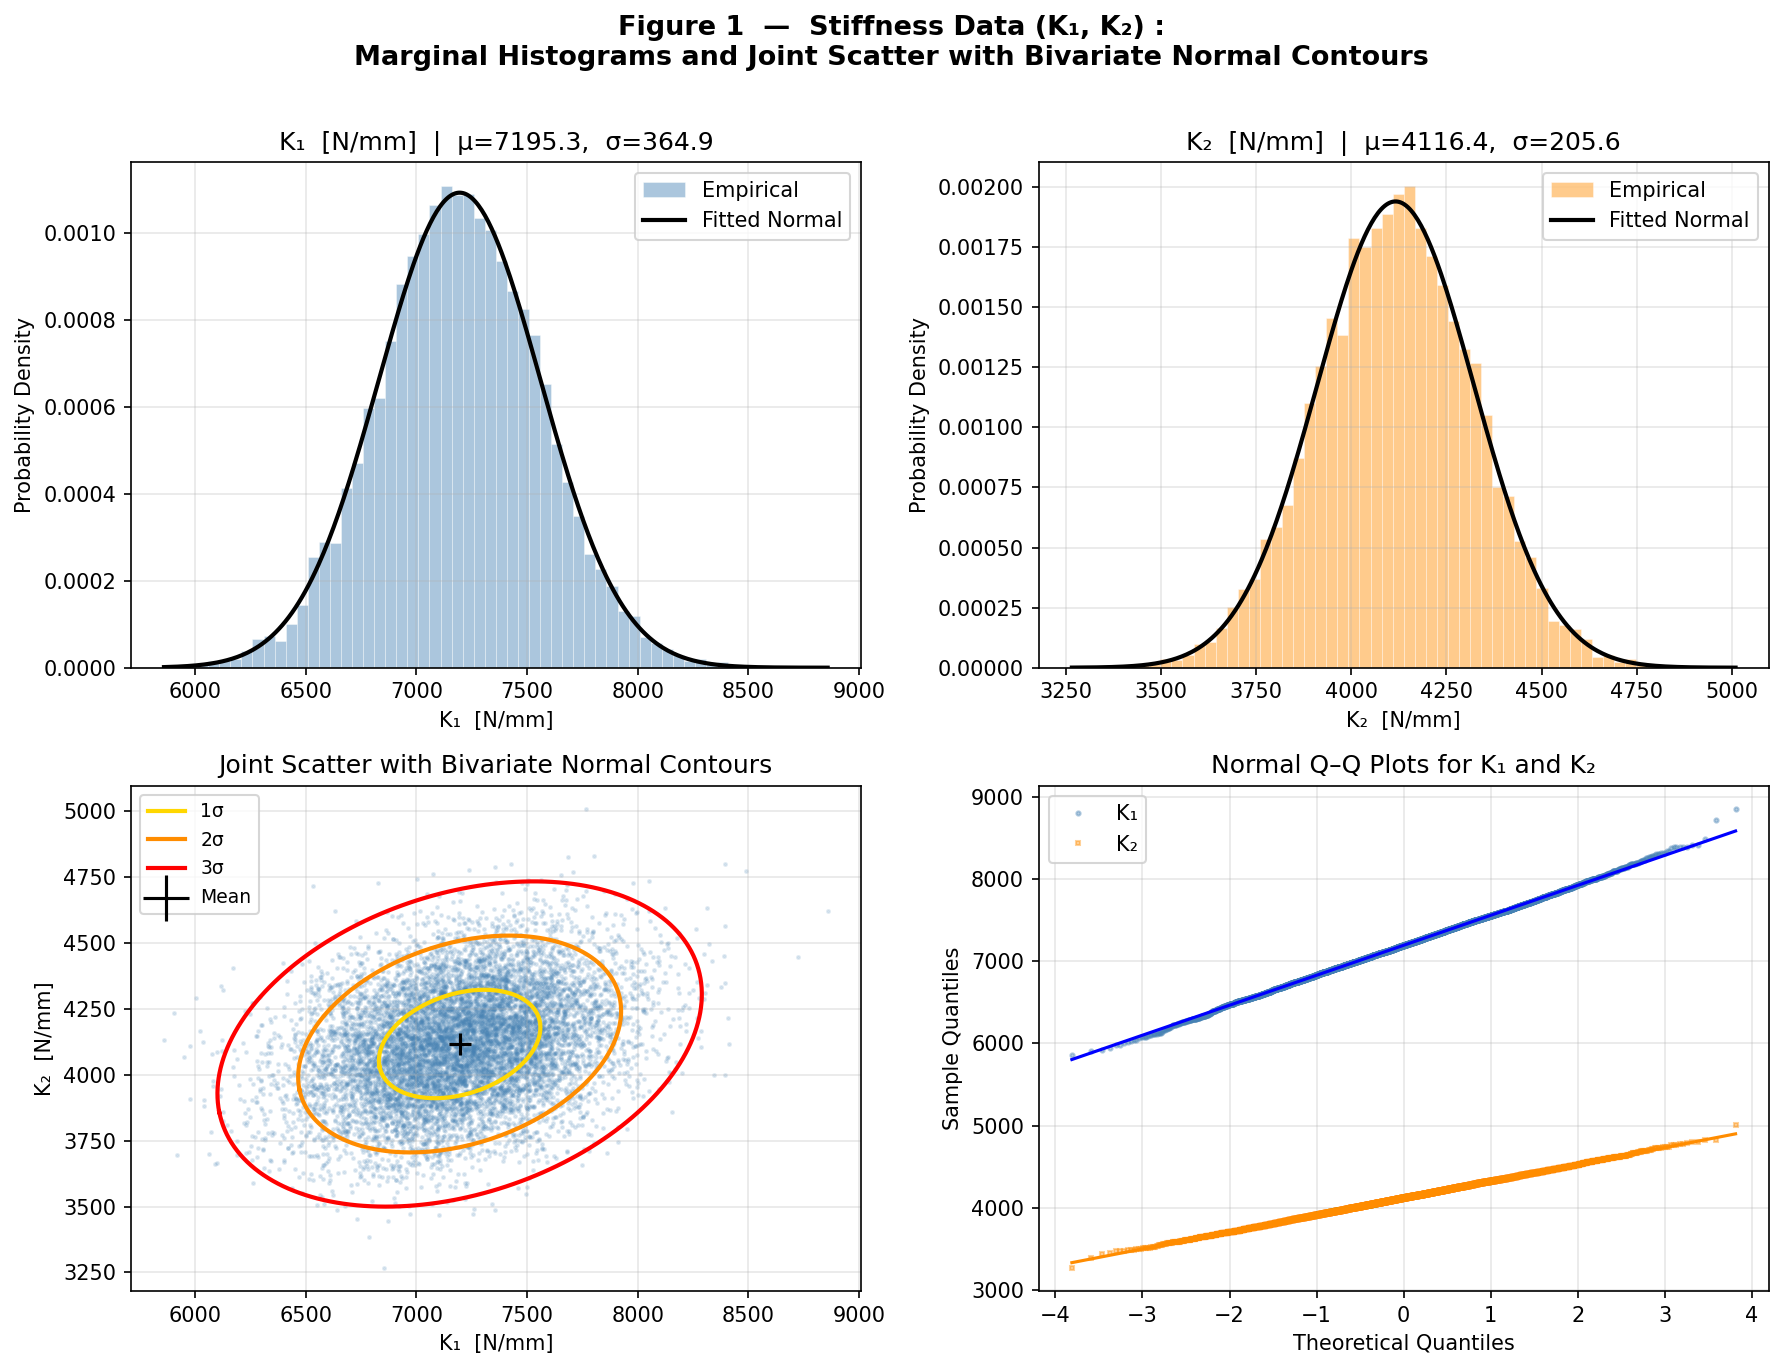

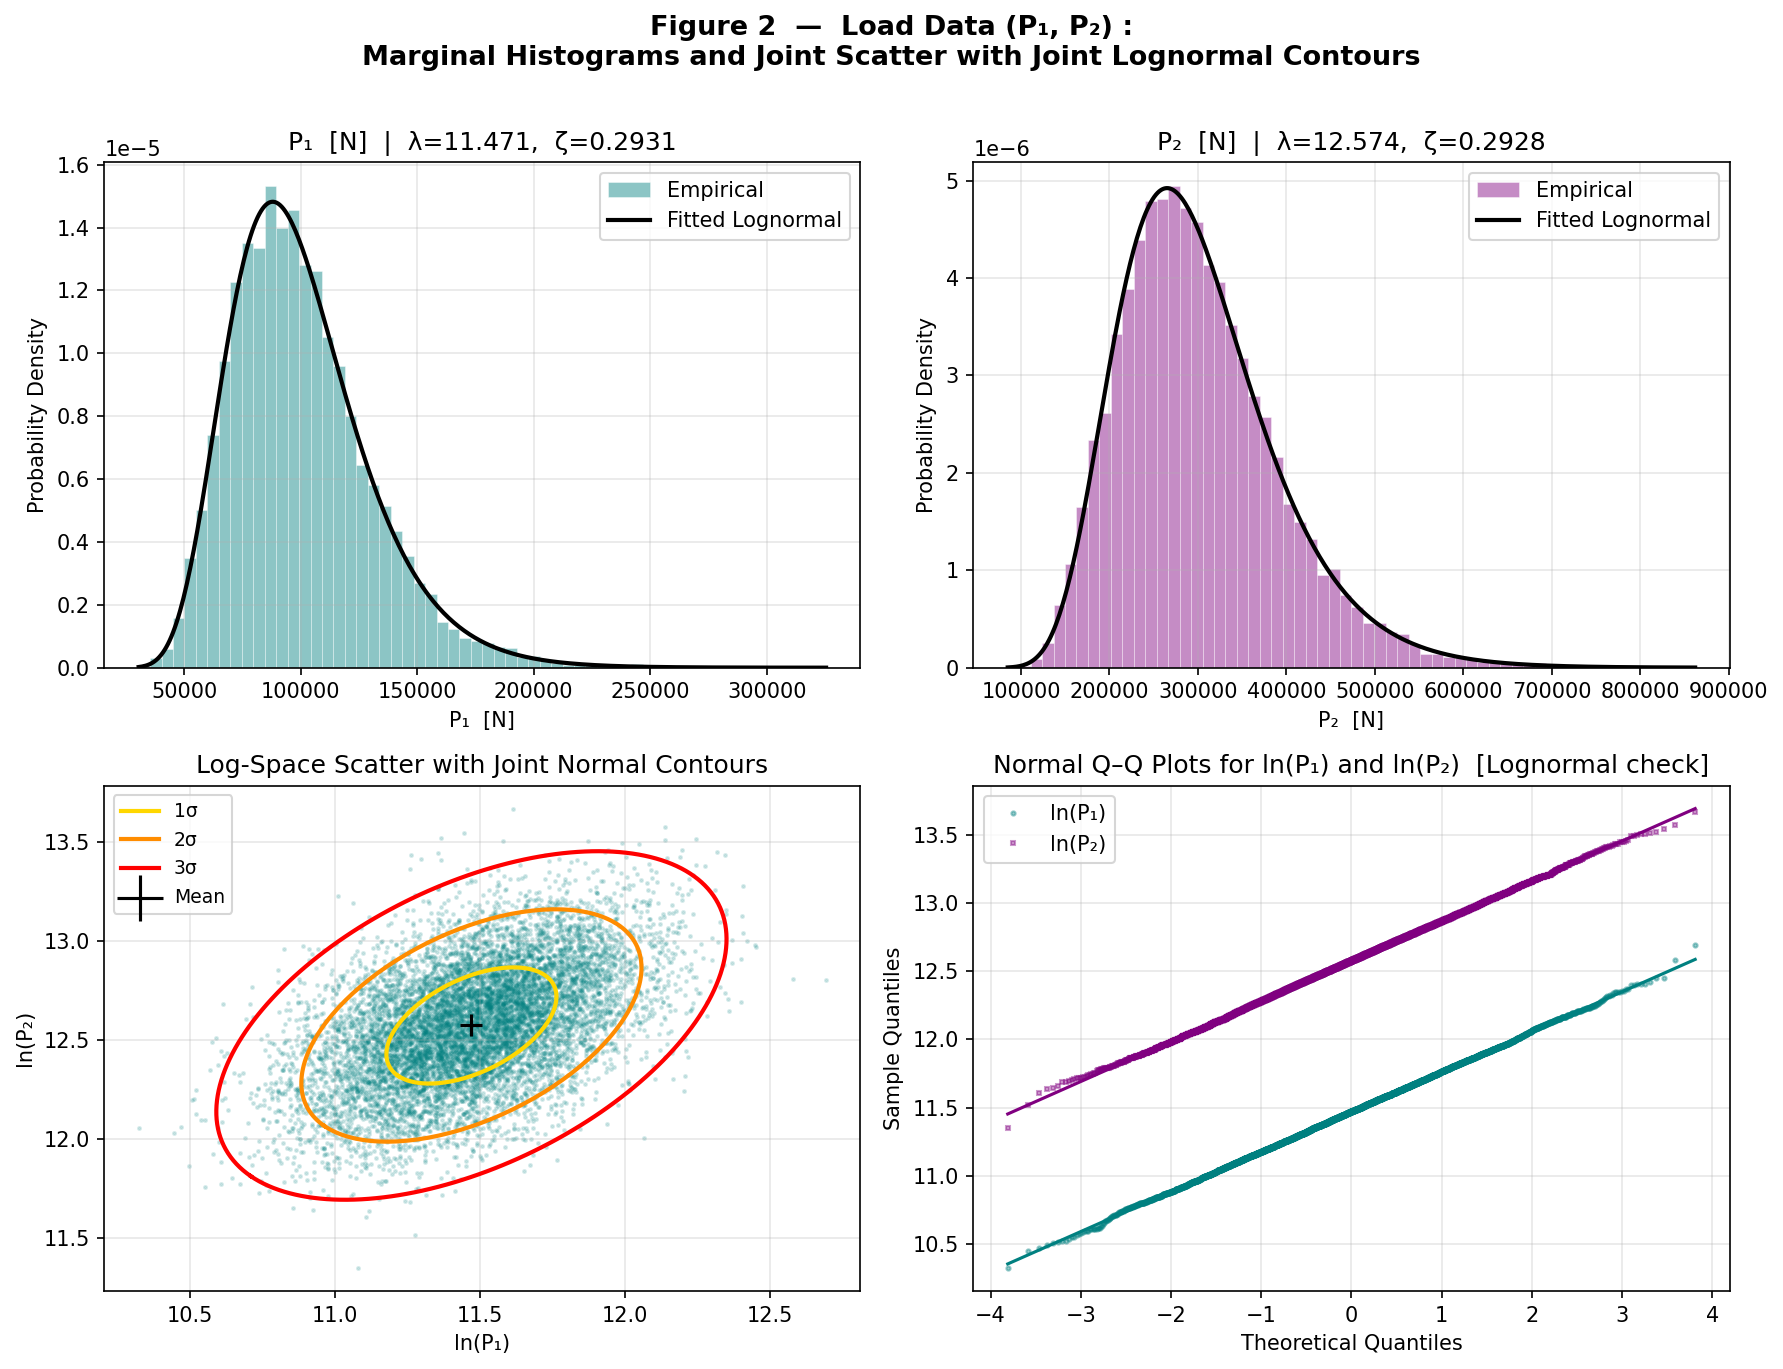

In [12]:
def plot_ellipse(ax, mu, Sigma, n_std=2, color='C1', lw=2, label=None):
    """Plot confidence ellipse for a bivariate normal."""
    vals, vecs = np.linalg.eigh(Sigma)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.linspace(0, 2*np.pi, 200)
    ellipse = n_std * (vecs @ np.diag(np.sqrt(vals)) @ np.array([np.cos(theta), np.sin(theta)]))
    ax.plot(mu[0]+ellipse[0], mu[1]+ellipse[1], color=color, lw=lw,
            label=label or f'{n_std}σ ellipse')
 
# ── Figure 1: K1 & K2 diagnostics ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Figure 1  —  Stiffness Data (K₁, K₂) :\n"
             "Marginal Histograms and Joint Scatter with Bivariate Normal Contours",
             fontsize=13, fontweight='bold', y=1.01)
 
for ax, data, mu, sigma, label, color in zip(
        axes.flat[:2],
        [K1, K2], [mu_K1, mu_K2], [sigma_K1, sigma_K2],
        ['K₁  [N/mm]', 'K₂  [N/mm]'], ['steelblue', 'darkorange']):
    ax.hist(data, bins=60, density=True, color=color, alpha=0.45,
            edgecolor='white', linewidth=0.4, label='Empirical')
    xg = np.linspace(data.min(), data.max(), 400)
    ax.plot(xg, stats.norm.pdf(xg, mu, sigma), 'k-', lw=2, label='Fitted Normal')
    ax.set_xlabel(label); ax.set_ylabel('Probability Density')
    ax.set_title(f'{label}  |  μ={mu:.1f},  σ={sigma:.1f}')
    ax.legend(); ax.grid(True, alpha=0.3)
 
# Scatter + ellipses
ax = axes[1, 0]
ax.scatter(K1, K2, s=2, alpha=0.15, color='steelblue', rasterized=True)
for ns, col in zip([1, 2, 3], ['gold', 'darkorange', 'red']):
    plot_ellipse(ax, mu_K, Sigma_K, n_std=ns, color=col, label=f'{ns}σ')
ax.scatter(*mu_K, marker='+', s=120, color='black', zorder=5, label='Mean')
ax.set_xlabel('K₁  [N/mm]'); ax.set_ylabel('K₂  [N/mm]')
ax.set_title('Joint Scatter with Bivariate Normal Contours')
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.3)
 
# QQ-plots side by side
ax = axes[1, 1]
(osm1, osr1), (slope1, intercept1, r1) = stats.probplot(K1, dist='norm')
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(K2, dist='norm')
ax.plot(osm1, osr1, 'o', ms=2, alpha=0.4, color='steelblue', label='K₁')
ax.plot(osm1, slope1*np.array(osm1)+intercept1, 'b-', lw=1.5)
ax.plot(osm2, osr2, 's', ms=2, alpha=0.4, color='darkorange', label='K₂')
ax.plot(osm2, slope2*np.array(osm2)+intercept2, '-', color='darkorange', lw=1.5)
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('Normal Q–Q Plots for K₁ and K₂')
ax.legend(); ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('Fig1_K_distribution_fitting.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("\n  → Saved: Fig1_K_distribution_fitting.png")
 
# ── Figure 2: P1 & P2 diagnostics ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Figure 2  —  Load Data (P₁, P₂) :\n"
             "Marginal Histograms and Joint Scatter with Joint Lognormal Contours",
             fontsize=13, fontweight='bold', y=1.01)
 
for ax, data, lam, zet, label, color in zip(
        axes.flat[:2],
        [P1, P2], [lambda_P1, lambda_P2], [zeta_P1, zeta_P2],
        ['P₁  [N]', 'P₂  [N]'], ['teal', 'purple']):
    ax.hist(data, bins=60, density=True, color=color, alpha=0.45,
            edgecolor='white', linewidth=0.4, label='Empirical')
    xg = np.linspace(data.min(), data.max(), 400)
    ax.plot(xg, stats.lognorm.pdf(xg, zet, scale=np.exp(lam)), 'k-', lw=2,
            label='Fitted Lognormal')
    ax.set_xlabel(label); ax.set_ylabel('Probability Density')
    ax.set_title(f'{label}  |  λ={lam:.3f},  ζ={zet:.4f}')
    ax.legend(); ax.grid(True, alpha=0.3)
 
# Scatter in log-space with Normal contours
lnP1 = np.log(P1); lnP2 = np.log(P2)
ax = axes[1, 0]
ax.scatter(lnP1, lnP2, s=2, alpha=0.15, color='teal', rasterized=True)
mu_lnP_vec = np.array([lambda_P1, lambda_P2])
for ns, col in zip([1, 2, 3], ['gold', 'darkorange', 'red']):
    plot_ellipse(ax, mu_lnP_vec, Sigma_lnP, n_std=ns, color=col, label=f'{ns}σ')
ax.scatter(*mu_lnP_vec, marker='+', s=120, color='black', zorder=5, label='Mean')
ax.set_xlabel('ln(P₁)'); ax.set_ylabel('ln(P₂)')
ax.set_title('Log-Space Scatter with Joint Normal Contours')
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.3)
 
# QQ-plots for lognormal
ax = axes[1, 1]
(osm1, osr1), (s1, i1, _) = stats.probplot(np.log(P1), dist='norm')
(osm2, osr2), (s2, i2, _) = stats.probplot(np.log(P2), dist='norm')
ax.plot(osm1, osr1, 'o', ms=2, alpha=0.4, color='teal',   label='ln(P₁)')
ax.plot(osm1, s1*np.array(osm1)+i1, '-', color='teal', lw=1.5)
ax.plot(osm2, osr2, 's', ms=2, alpha=0.4, color='purple', label='ln(P₂)')
ax.plot(osm2, s2*np.array(osm2)+i2, '-', color='purple', lw=1.5)
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('Normal Q–Q Plots for ln(P₁) and ln(P₂)  [Lognormal check]')
ax.legend(); ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('Fig2_P_distribution_fitting.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("  → Saved: Fig2_P_distribution_fitting.png")




print("\nDisplaying saved distribution fitting plots:")

display(Image(filename='Fig1_K_distribution_fitting.png'))
display(Image(filename='Fig2_P_distribution_fitting.png'))

<h1>LIMIT STATE FUNCTION</h1>

The structure is a two-storey shear-type building. Each storey has three identical columns acting in parallel, so the effective storey stiffnesses are

$$
k_1=3K_1,
\qquad
k_2=3K_2.
$$

The roof displacement is obtained from static equilibrium and is given by

$$
u_{\text{roof}}
=
\frac{P_1+P_2}{3K_1}
+
\frac{P_2}{3K_2}.
$$

Failure occurs when the roof displacement exceeds the allowable displacement

$$
d_{\max}=100\;\mathrm{mm}.
$$

Therefore, the limit-state function is

$$
g(K_1,K_2,P_1,P_2)
=
d_{\max}
-
\frac{P_1+P_2}{3K_1}
-
\frac{P_2}{3K_2}.
$$

The safe and failure domains are

$$
g>0 \quad \text{safe},
$$

and

$$
g\leq 0 \quad \text{failure}.
$$

In [13]:
P1_nom = 2.04e5   # [N]
P2_nom = 6.12e5   # [N]
d_max  = 100.0    # [mm]
 
print("\n  Physical parameters:")
print(f"    P1_nom = {P1_nom:.3e} N")
print(f"    P2_nom = {P2_nom:.3e} N")
print(f"    d_max  = {d_max} mm")
print("\n  Stiffness matrix (3 parallel columns per storey):")
print("    k_eff_i = 3·Ki  [N/mm]")
print("\n  Roof displacement:")
print("    u_roof = (P1+P2)/(3·K1) + P2/(3·K2)")
print("\n  Limit state function (failure: u_roof > 100 mm):")
print("    g(K1,K2) = 100 - (P1_nom+P2_nom)/(3·K1) - P2_nom/(3·K2)")
 
def u_roof(K1, K2, P1=P1_nom, P2=P2_nom):
    """Roof horizontal displacement [mm]."""
    return (P1 + P2)/(3.0*K1) + P2/(3.0*K2)
 
def g_lsf(K1, K2, P1=P1_nom, P2=P2_nom):
    """Limit state: g > 0  → safe,  g < 0  → failure."""
    return d_max - u_roof(K1, K2, P1, P2)

# Verify at mean values
u_mean = u_roof(mu_K1, mu_K2)
g_mean = g_lsf(mu_K1, mu_K2)
print(f"\n  At mean (μ_K1={mu_K1:.1f}, μ_K2={mu_K2:.1f}):")
print(f"    u_roof = {u_mean:.4f} mm   →  g = {g_mean:.4f}  ({'SAFE' if g_mean>0 else 'FAIL'})")


  Physical parameters:
    P1_nom = 2.040e+05 N
    P2_nom = 6.120e+05 N
    d_max  = 100.0 mm

  Stiffness matrix (3 parallel columns per storey):
    k_eff_i = 3·Ki  [N/mm]

  Roof displacement:
    u_roof = (P1+P2)/(3·K1) + P2/(3·K2)

  Limit state function (failure: u_roof > 100 mm):
    g(K1,K2) = 100 - (P1_nom+P2_nom)/(3·K1) - P2_nom/(3·K2)

  At mean (μ_K1=7195.3, μ_K2=4116.4):
    u_roof = 87.3600 mm   →  g = 12.6400  (SAFE)


<h1>Case 1 definition: fixed nominal loads</h1>

In Case 1, the loads are fixed at their nominal values:

$$
P_1^{\text{nom}}=2.04\times10^5\;\mathrm{N},
$$

$$
P_2^{\text{nom}}=6.12\times10^5\;\mathrm{N}.
$$

Only the stiffness variables are random:

$$
\mathbf{K}
=
\begin{bmatrix}
K_1\\
K_2
\end{bmatrix}.
$$

Thus, the limit-state function becomes

$$
g(K_1,K_2)
=
100
-
\frac{P_1^{\text{nom}}+P_2^{\text{nom}}}{3K_1}
-
\frac{P_2^{\text{nom}}}{3K_2}.
$$

This is a two-dimensional reliability problem because only $(K_1)$ and $(K_2)$ are treated as random variables.

<h2>Case 1 transformation to standard normal space</h2>

Since \(K_1\) and \(K_2\) are modeled as correlated normal variables, the transformation between physical space and standard normal space is linear.

Using the Cholesky factor \(\mathbf{L}_K\) of the covariance matrix,

$$
\boldsymbol{\Sigma}_K=\mathbf{L}_K\mathbf{L}_K^T,
$$

the transformation from standard normal space to physical space is

$$
\mathbf{K}
=
\boldsymbol{\mu}_K+\mathbf{L}_K\mathbf{u}.
$$

The inverse transformation is

$$
\mathbf{u}
=
\mathbf{L}_K^{-1}
(\mathbf{K}-\boldsymbol{\mu}_K).
$$

The transformed limit-state function is therefore

$$
G(\mathbf{u})
=
g\left(\boldsymbol{\mu}_K+\mathbf{L}_K\mathbf{u}\right).
$$

This form allows the HLRF algorithm to search for the design point in independent standard normal space.

In [14]:
"""
For correlated Normals use Cholesky of covariance:
  X = μ + L·U   where L = cholesky(Σ, lower=True), U ~ N(0, I)
  U = L^{-1}·(X - μ)   ← standard normal space
"""
L_K    = np.linalg.cholesky(Sigma_K)     # lower-triangular Cholesky
L_K_inv = np.linalg.inv(L_K)
 
def x_to_u(x):
    """Original → Standard Normal space (bivariate Normal)."""
    return L_K_inv @ (x - mu_K)
 
def u_to_x(u):
    """Standard Normal → Original space."""
    return mu_K + L_K @ u

<h1> HLRF ALGORITHM IN STANDARD NORMAL SPACE</h1>



The HLRF algorithm searches for the design point $(\mathbf{u}^*)$, which is the point on the failure surface closest to the origin in standard normal space.

The failure surface is

$$
G(\mathbf{u})=0.
$$

The HLRF update equation is

$$
\mathbf{u}^{(k+1)}
=
\frac{
\nabla G(\mathbf{u}^{(k)})^T\mathbf{u}^{(k)}
-
G(\mathbf{u}^{(k)})
}
{
\left\|\nabla G(\mathbf{u}^{(k)})\right\|^2
}
\nabla G(\mathbf{u}^{(k)}).
$$

After convergence, the reliability index is

$$
\beta=\|\mathbf{u}^*\|,
$$

and the FORM estimate of the probability of failure is

$$
P_f^{\mathrm{FORM}}=\Phi(-\beta).
$$

In [15]:
def g_in_u(u):
    """LSF evaluated in U-space."""
    x = u_to_x(u)
    return g_lsf(x[0], x[1])
 
def grad_g_in_u(u, eps=1e-5):
    """Numerical gradient of g w.r.t. U (central finite differences)."""
    grad = np.zeros(2)
    for i in range(2):
        u_p = u.copy(); u_p[i] += eps
        u_m = u.copy(); u_m[i] -= eps
        grad[i] = (g_in_u(u_p) - g_in_u(u_m)) / (2*eps)
    return grad
 
def hlrf(start_u=None, max_iter=50, tol=1e-6):
    """
    Hasofer-Lind-Rackwitz-Fiessler (HLRF) algorithm.
    Returns history of (u, beta, g_val) at each iteration.
    """
    if start_u is None:
        start_u = x_to_u(mu_K)   # start at mean in U-space
 
    u     = start_u.copy()
    history = []
 
    for k in range(max_iter):
        x     = u_to_x(u)
        g_val = g_in_u(u)
        nabla = grad_g_in_u(u)
        norm_nabla = np.linalg.norm(nabla)
        alpha = -nabla / norm_nabla           # sensitivity vector (unit)
        beta  = (nabla @ u - g_val) / norm_nabla
 
        history.append({
            'iter': k,
            'K1': x[0], 'K2': x[1],
            'u1': u[0], 'u2': u[1],
            'g': g_val,
            '|∇g|': norm_nabla,
            'β': beta,
            'α1': alpha[0], 'α2': alpha[1],
        })
 
        # HLRF update rule
        u_new = (nabla @ u - g_val) / norm_nabla**2 * nabla
 
        # Convergence check
        if np.linalg.norm(u_new - u) < tol and abs(g_val) < tol:
            u = u_new
            x = u_to_x(u)
            g_val = g_in_u(u)
            nabla = grad_g_in_u(u)
            norm_nabla = np.linalg.norm(nabla)
            alpha = -nabla / norm_nabla
            beta  = np.linalg.norm(u)
            history.append({
                'iter': k+1,
                'K1': x[0], 'K2': x[1],
                'u1': u[0], 'u2': u[1],
                'g': g_val,
                '|∇g|': norm_nabla,
                'β': beta,
                'α1': alpha[0], 'α2': alpha[1],
            })
            break
        u = u_new
 
    return history
 
# Run HLRF
history = hlrf()
 
# Extract results
dp_u  = np.array([history[-1]['u1'], history[-1]['u2']])
dp_x  = u_to_x(dp_u)
beta  = np.linalg.norm(dp_u)
pf_FORM = stats.norm.cdf(-beta)

<h1>ITERATION TABLE</h1>

In [16]:
print("\n──────────────────────────────────────────────────────────────────────")
print("  HLRF ITERATION TABLE (Case 1: Bivariate Normal K1, K2 — Fixed Loads)")
print("──────────────────────────────────────────────────────────────────────")
header = f"{'Iter':>4}  {'K1':>10}  {'K2':>10}  {'u1':>8}  {'u2':>8}  "
header += f"{'g(X)':>12}  {'|∇g|':>10}  {'β':>8}"
print(header)
print("-" * len(header))
for h in history:
    print(f"{h['iter']:>4}  {h['K1']:>10.4f}  {h['K2']:>10.4f}  "
          f"{h['u1']:>8.5f}  {h['u2']:>8.5f}  "
          f"{h['g']:>12.6f}  {h['|∇g|']:>10.6f}  {h['β']:>8.6f}")
 
print(f"\n  ──────────────────────────────────────────────")
print(f"  CONVERGED RESULTS (Fixed-Load HLRF):")
print(f"    Design point (original space):")
print(f"      K1* = {dp_x[0]:.4f} N/mm")
print(f"      K2* = {dp_x[1]:.4f} N/mm")
print(f"    Design point (standard normal space):")
print(f"      u1* = {dp_u[0]:.6f}")
print(f"      u2* = {dp_u[1]:.6f}")
print(f"    Reliability index:  β = {beta:.6f}")
print(f"    FORM Pf estimate:   Pf = Φ(-β) = {pf_FORM:.6e}")
print(f"    u_roof at DP:       {u_roof(dp_x[0], dp_x[1]):.4f} mm")
print(f"    Sensitivity α = [{history[-1]['α1']:.4f},  {history[-1]['α2']:.4f}]")


──────────────────────────────────────────────────────────────────────
  HLRF ITERATION TABLE (Case 1: Bivariate Normal K1, K2 — Fixed Loads)
──────────────────────────────────────────────────────────────────────
Iter          K1          K2        u1        u2          g(X)        |∇g|         β
------------------------------------------------------------------------------------
   0   7195.2941   4116.4333   0.00000   0.00000     12.640049    3.563549  -3.547040
   1   6224.8045   3490.0230  -2.65991  -2.34656     -2.148488    4.878907  -3.106314
   2   6356.2081   3563.2285  -2.29976  -2.08813     -0.044259    4.680018  -3.096857
   3   6358.8330   3564.8832  -2.29257  -2.08198     -0.000020    4.675861  -3.096853
   4   6358.8066   3564.8955  -2.29264  -2.08190     -0.000000    4.675856  -3.096853
   5   6358.8026   3564.8972  -2.29265  -2.08189     -0.000000    4.675856  -3.096853
   6   6358.8020   3564.8975  -2.29265  -2.08188     -0.000000    4.675856  -3.096853
   7   6358.80

<h1>Case 1 design point search plots</h1>


  → Saved: Fig3_HLRF_fixed_loads_design_point.png


## Figure 3 — HLRF Design Point Search Sequence: Case 1

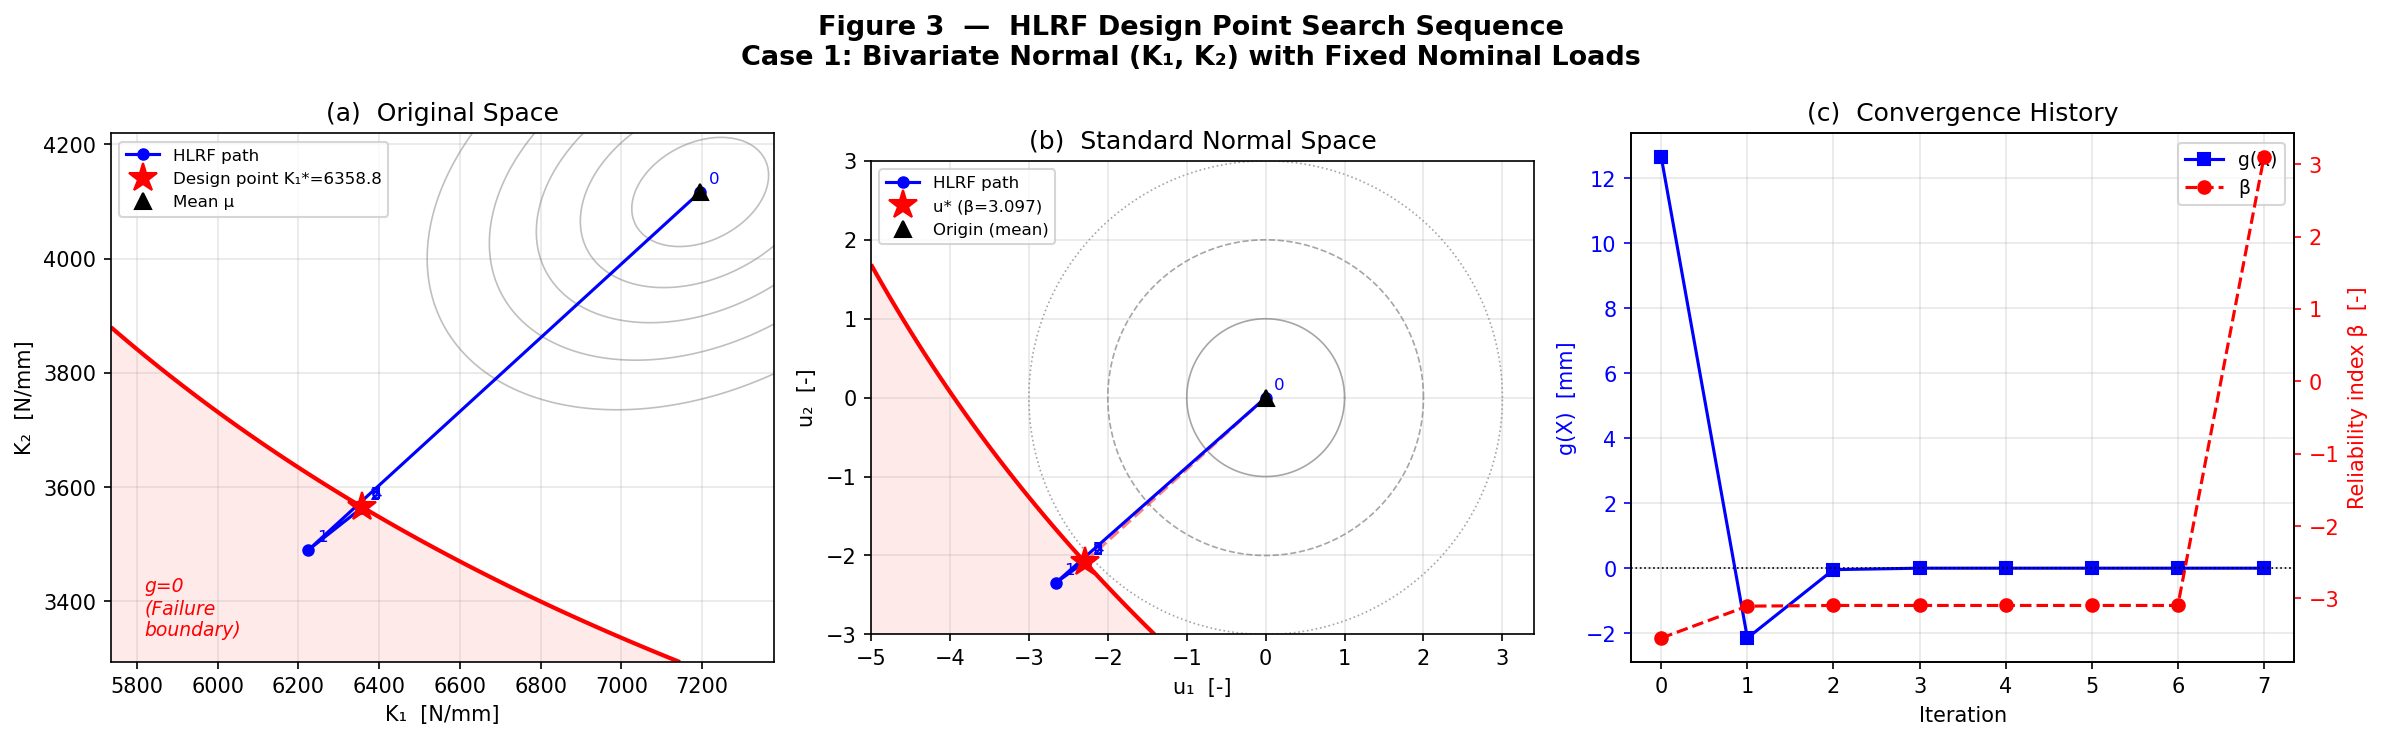

In [19]:
iters  = [h['iter'] for h in history]
K1_seq = [h['K1']   for h in history]
K2_seq = [h['K2']   for h in history]
u1_seq = [h['u1']   for h in history]
u2_seq = [h['u2']   for h in history]
g_seq  = [h['g']    for h in history]
b_seq  = [h['β']    for h in history]
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 3  —  HLRF Design Point Search Sequence\n"
             "Case 1: Bivariate Normal (K₁, K₂) with Fixed Nominal Loads",
             fontsize=13, fontweight='bold')
 
# ── subplot A: X-space ───────────────────────────────────────────────────────
ax = axes[0]
# LSF contour in X-space
K1g = np.linspace(mu_K1-4*sigma_K1, mu_K1+0.5*sigma_K1, 300)
K2g = np.linspace(mu_K2-4*sigma_K2, mu_K2+0.5*sigma_K2, 300)
K1G, K2G = np.meshgrid(K1g, K2g)
GG = g_lsf(K1G, K2G)
ax.contour(K1G, K2G, GG, levels=[0], colors='red', linewidths=2)
ax.contourf(K1G, K2G, GG, levels=[-1e9, 0], colors=['#ffcccc'], alpha=0.4)
ax.annotate('g=0\n(Failure\nboundary)', xy=(K1g[15], K2g[15]),
            color='red', fontsize=9, fontstyle='italic')
 
# PDF contours
from scipy.stats import multivariate_normal
mvn = multivariate_normal(mu_K, Sigma_K)
PDF = mvn.pdf(np.dstack([K1G, K2G]))
ax.contour(K1G, K2G, PDF, levels=6, colors='gray', alpha=0.5, linewidths=0.8)
 
# Search path
ax.plot(K1_seq, K2_seq, 'b-o', ms=5, lw=1.5, label='HLRF path', zorder=5)
for i, (k1, k2) in enumerate(zip(K1_seq, K2_seq)):
    ax.annotate(str(i), (k1, k2), textcoords='offset points',
                xytext=(4, 4), fontsize=8, color='blue')
ax.plot(dp_x[0], dp_x[1], 'r*', ms=14, label=f'Design point K₁*={dp_x[0]:.1f}', zorder=6)
ax.plot(mu_K1, mu_K2, 'k^', ms=8, label='Mean μ', zorder=6)
ax.set_xlabel('K₁  [N/mm]'); ax.set_ylabel('K₂  [N/mm]')
ax.set_title('(a)  Original Space')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
 
# ── subplot B: U-space ───────────────────────────────────────────────────────
ax = axes[1]
u1g = np.linspace(-5, 1, 300)
u2g = np.linspace(-3, 3, 300)
U1G, U2G = np.meshgrid(u1g, u2g)
GU = np.array([[g_in_u(np.array([u1, u2])) for u1 in u1g] for u2 in u2g])
ax.contour(U1G, U2G, GU, levels=[0], colors='red', linewidths=2)
ax.contourf(U1G, U2G, GU, levels=[-1e9, 0], colors=['#ffcccc'], alpha=0.4)
 
# Standard normal circles
for r, ls in zip([1,2,3], ['-','--',':']):
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(r*np.cos(theta), r*np.sin(theta), 'gray', ls=ls, lw=0.8, alpha=0.7)
 
ax.plot(u1_seq, u2_seq, 'b-o', ms=5, lw=1.5, label='HLRF path', zorder=5)
for i, (u1, u2) in enumerate(zip(u1_seq, u2_seq)):
    ax.annotate(str(i), (u1, u2), textcoords='offset points',
                xytext=(4, 4), fontsize=8, color='blue')
ax.plot(dp_u[0], dp_u[1], 'r*', ms=14, label=f'u* (β={beta:.3f})', zorder=6)
ax.plot(0, 0, 'k^', ms=8, label='Origin (mean)', zorder=6)
ax.plot([0, dp_u[0]], [0, dp_u[1]], 'r--', lw=1.5, alpha=0.5)
ax.set_xlabel('u₁  [-]'); ax.set_ylabel('u₂  [-]')
ax.set_title('(b)  Standard Normal Space')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
 
# ── subplot C: convergence ────────────────────────────────────────────────────
ax = axes[2]
ax2 = ax.twinx()
ax.plot(iters, g_seq, 'b-s', ms=6, lw=1.5, label='g(X)')
ax2.plot(iters, b_seq, 'r-o', ms=6, lw=1.5, label='β', linestyle='--')
ax.axhline(0, color='k', lw=0.8, linestyle=':')
ax.set_xlabel('Iteration'); ax.set_ylabel('g(X)  [mm]', color='blue')
ax2.set_ylabel('Reliability index β  [-]', color='red')
ax.set_title('(c)  Convergence History')
ax.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('Fig3_HLRF_fixed_loads_design_point.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("\n  → Saved: Fig3_HLRF_fixed_loads_design_point.png")

display(Markdown("## Figure 3 — HLRF Design Point Search Sequence: Case 1"))

display(Image(filename='Fig3_HLRF_fixed_loads_design_point.png'))

<h1>Case 2 definition: random stiffnesses and random loads</h1>



In Case 2, all four variables are treated as random:

$$
\mathbf{X}
=
\begin{bmatrix}
K_1\\
K_2\\
P_1\\
P_2
\end{bmatrix}.
$$

The stiffness variables are modeled as correlated normal variables:

$$
\mathbf{K}\sim\mathcal{N}(\boldsymbol{\mu}_K,\boldsymbol{\Sigma}_K),
$$

while the load variables are modeled as correlated lognormal variables:

$$
\ln\mathbf{P}\sim
\mathcal{N}(\boldsymbol{\mu}_{\ln P},\boldsymbol{\Sigma}_{\ln P}).
$$

The limit-state function is now

$$
g(K_1,K_2,P_1,P_2)
=
100
-
\frac{P_1+P_2}{3K_1}
-
\frac{P_2}{3K_2}.
$$

This is a four-dimensional reliability problem.

<h1>Transformation Matrices</h1>

The four-dimensional transformation is constructed in two blocks.

For the stiffness variables:

$$
\mathbf{K}
=
\boldsymbol{\mu}_K+\mathbf{L}_K\mathbf{u}_K.
$$

For the load variables, the transformation is applied in log-space:

$$
\ln\mathbf{P}
=
\boldsymbol{\mu}_{\ln P}
+
\mathbf{L}_{\ln P}\mathbf{u}_P.
$$

Then the physical loads are recovered by exponentiation:

$$
\mathbf{P}
=
\exp(\ln\mathbf{P}).
$$

Therefore, the full standard normal vector is

$$
\mathbf{u}
=
\begin{bmatrix}
u_{K_1}\\
u_{K_2}\\
u_{P_1}\\
u_{P_2}
\end{bmatrix}.
$$

The transformation maps $(\mathbf{u})$ into the physical variables

$$
\mathbf{x}
=
(K_1,K_2,P_1,P_2)^T.
$$

In [20]:
L_lnP     = np.linalg.cholesky(Sigma_lnP)
L_lnP_inv = np.linalg.inv(L_lnP)
 
d_max = 100.0   # [mm]
 
def u_to_x_4D(u):
    """Standard normal U=[u_K1, u_K2, u_P1, u_P2] → physical [K1,K2,P1,P2]."""
    u_K = u[:2]; u_P = u[2:]
    K   = mu_K  + L_K    @ u_K                  # K vector (Normal)
    lnP = mu_lnP + L_lnP @ u_P                  # ln(P) vector
    P   = np.exp(lnP)                            # P vector (Lognormal)
    return np.concatenate([K, P])
 
def x_to_u_4D(x):
    """Physical [K1,K2,P1,P2] → standard normal U."""
    K   = x[:2]; P = x[2:]
    u_K = L_K_inv    @ (K   - mu_K)
    u_P = L_lnP_inv  @ (np.log(P) - mu_lnP)
    return np.concatenate([u_K, u_P])
 
def g_4D(x):
    """Limit state in original space."""
    K1, K2, P1, P2 = x
    return d_max - (P1+P2)/(3.0*K1) - P2/(3.0*K2)
 
def g_in_u_4D(u):
    return g_4D(u_to_x_4D(u))
 
def grad_g_in_u_4D(u, eps=1e-6):
    grad = np.zeros(4)
    for i in range(4):
        u_p = u.copy(); u_p[i] += eps
        u_m = u.copy(); u_m[i] -= eps
        grad[i] = (g_in_u_4D(u_p) - g_in_u_4D(u_m)) / (2*eps)
    return grad

# Case 2 — Transformed Limit-State Function

The transformed limit-state function is

$$
G(\mathbf{u})
=
g\left(T^{-1}(\mathbf{u})\right),
$$

where $(T^{-1})$ maps the standard normal vector into the physical variables:

$$
\mathbf{u}
\longrightarrow
(K_1,K_2,P_1,P_2).
$$

Because the load transformation involves exponentials, $(G(\mathbf{u}))$ is nonlinear in standard normal space.

The gradient

$$
\nabla G(\mathbf{u})
$$

is evaluated numerically using central finite differences. This avoids deriving a long analytical expression for the derivative of the transformed lognormal variables.

<h1>Case 2 HLRF algorithm (4D)</h1>



The HLRF algorithm is now applied in four-dimensional standard normal space.

The update equation remains

$$
\mathbf{u}^{(k+1)}
=
\frac{
\nabla G(\mathbf{u}^{(k)})^T\mathbf{u}^{(k)}
-
G(\mathbf{u}^{(k)})
}
{
\left\|\nabla G(\mathbf{u}^{(k)})\right\|^2
}
\nabla G(\mathbf{u}^{(k)}).
$$

After convergence, the reliability index is

$$
\beta=\|\mathbf{u}^*\|,
$$

and the FORM probability of failure is

$$
P_f^{\mathrm{FORM}}=\Phi(-\beta).
$$

In this case, the relative magnitudes of $(u_{K_1}^*,u_{K_2}^*,u_{P_1}^*,u_{P_2}^*)$ indicate whether failure is controlled more strongly by stiffness uncertainty or load uncertainty.

In [21]:
def hlrf_4D(max_iter=100, tol=1e-7):
    # Start at the mean point of all random variables
    mu_X = np.array([
        mu_K1,
        mu_K2,
        np.exp(lambda_P1 + 0.5*zeta_P1**2),
        np.exp(lambda_P2 + 0.5*zeta_P2**2)
    ])

    u = x_to_u_4D(mu_X)

    history = []

    for k in range(max_iter):
        x     = u_to_x_4D(u)
        g_val = g_in_u_4D(u)
        nabla = grad_g_in_u_4D(u)
        norm  = np.linalg.norm(nabla)

        alpha = -nabla / norm
        beta  = (nabla @ u - g_val) / norm

        history.append({
            'iter': k,
            'K1': x[0], 'K2': x[1], 'P1': x[2], 'P2': x[3],
            'u1': u[0], 'u2': u[1], 'u3': u[2], 'u4': u[3],
            'g': g_val,
            '|∇g|': norm,
            'β': beta,
            'α1': alpha[0], 'α2': alpha[1],
            'α3': alpha[2], 'α4': alpha[3],
        })

        # HLRF update
        u_new = ((nabla @ u - g_val) / norm**2) * nabla

        if np.linalg.norm(u_new - u) < tol and abs(g_val) < 1e-4:
            u = u_new
            x = u_to_x_4D(u)
            g_val = g_in_u_4D(u)
            nabla = grad_g_in_u_4D(u)
            norm  = np.linalg.norm(nabla)
            alpha = -nabla / norm
            beta  = np.linalg.norm(u)

            history.append({
                'iter': k+1,
                'K1': x[0], 'K2': x[1], 'P1': x[2], 'P2': x[3],
                'u1': u[0], 'u2': u[1], 'u3': u[2], 'u4': u[3],
                'g': g_val,
                '|∇g|': norm,
                'β': beta,
                'α1': alpha[0], 'α2': alpha[1],
                'α3': alpha[2], 'α4': alpha[3],
            })
            break

        u = u_new

    return history


history4 = hlrf_4D()

dp_u4 = np.array([
    history4[-1]['u1'],
    history4[-1]['u2'],
    history4[-1]['u3'],
    history4[-1]['u4']
])

dp_x4 = u_to_x_4D(dp_u4)
beta4 = np.linalg.norm(dp_u4)
pf4   = stats.norm.cdf(-beta4)

<h1>ITERATION TABLE</h1>

The four-dimensional design point is

$$
\mathbf{u}^*
=
(u_{K_1}^*,u_{K_2}^*,u_{P_1}^*,u_{P_2}^*).
$$

The corresponding physical design point is

$$
\mathbf{x}^*
=
(K_1^*,K_2^*,P_1^*,P_2^*).
$$

At convergence,

$$
g(\mathbf{x}^*)\approx 0.
$$

If the load components $(u_{P_1}^*)$ and $(u_{P_2}^*)$ are larger in magnitude than the stiffness components, then failure is mainly driven by unusually high load realizations. If the stiffness components dominate, then failure is mainly driven by unusually low stiffness values.

In [22]:
print("\n──────────────────────────────────────────────────────────────────────────────────")
print("  HLRF ITERATION TABLE (Case 2: All 4 RVs — K Normal, P Lognormal)")
print("──────────────────────────────────────────────────────────────────────────────────")
hdr = (f"{'Iter':>4}  {'K1':>9}  {'K2':>9}  {'P1':>11}  {'P2':>12}  "
       f"{'u1':>8}  {'u2':>8}  {'u3':>8}  {'u4':>8}  {'g':>11}  {'β':>8}")
print(hdr)
print("-" * len(hdr))
for h in history4:
    print(f"{h['iter']:>4}  {h['K1']:>9.2f}  {h['K2']:>9.2f}  {h['P1']:>11.1f}  {h['P2']:>12.1f}  "
          f"{h['u1']:>8.5f}  {h['u2']:>8.5f}  {h['u3']:>8.5f}  {h['u4']:>8.5f}  "
          f"{h['g']:>11.5f}  {h['β']:>8.5f}")
 
print(f"\n  ──────────────────────────────────────────────")
print(f"  CONVERGED RESULTS (Probabilistic Loads HLRF):")
print(f"    Design point (original space):")
print(f"      K1* = {dp_x4[0]:.4f} N/mm")
print(f"      K2* = {dp_x4[1]:.4f} N/mm")
print(f"      P1* = {dp_x4[2]:.2f} N")
print(f"      P2* = {dp_x4[3]:.2f} N")
print(f"    Design point (standard normal space):")
print(f"      u1* = {dp_u4[0]:.6f}  (K1)")
print(f"      u2* = {dp_u4[1]:.6f}  (K2)")
print(f"      u3* = {dp_u4[2]:.6f}  (P1)")
print(f"      u4* = {dp_u4[3]:.6f}  (P2)")
print(f"    Reliability index:  β = {beta4:.6f}")
print(f"    FORM Pf estimate:   Pf = Φ(-β) = {pf4:.6e}")
 


──────────────────────────────────────────────────────────────────────────────────
  HLRF ITERATION TABLE (Case 2: All 4 RVs — K Normal, P Lognormal)
──────────────────────────────────────────────────────────────────────────────────
Iter         K1         K2           P1            P2        u1        u2        u3        u4            g         β
--------------------------------------------------------------------------------------------------------------------
   0    7195.29    4116.43     100089.2      301457.3   0.00000   0.00000   0.14653   0.08498     56.98684  -4.86290
   1    7002.38    3991.85     216848.4     1173697.4  -0.52873  -0.46677   2.78462   3.92381    -64.20166  -3.49682
   2    7060.27    4023.39     166370.2      793978.3  -0.37006  -0.35658   1.88045   2.90303    -11.12073  -3.14688
   3    7073.61    4033.44     158327.0      717344.2  -0.33352  -0.31695   1.71136   2.60046     -0.54781  -3.12778
   4    7074.05    4034.19     158239.7      713271.4  -0.33229 

<h1>Case 2 design point search plots</h1>

Because Case 2 is four-dimensional, the design point search cannot be fully visualized in one two-dimensional plot.

Instead, the HLRF path is shown using projections such as:

- $(K_1)$-$(K_2)$ physical space,
- $(u_1)$-$(u_2)$ standard normal space for the stiffness block,
- $(u_3)$-$(u_4)$ standard normal space for the load block,
- selected cross-planes such as $(K_1)$-$(P_2$),
- convergence of $(g(\mathbf{x}))$,
- evolution of the reliability index $(\beta)$.

These projections help interpret which variables control the failure event.


  → Saved: Fig4_HLRF_probabilistic_loads.png


## Figure 4 — HLRF Design Point Search Sequence: Case 2

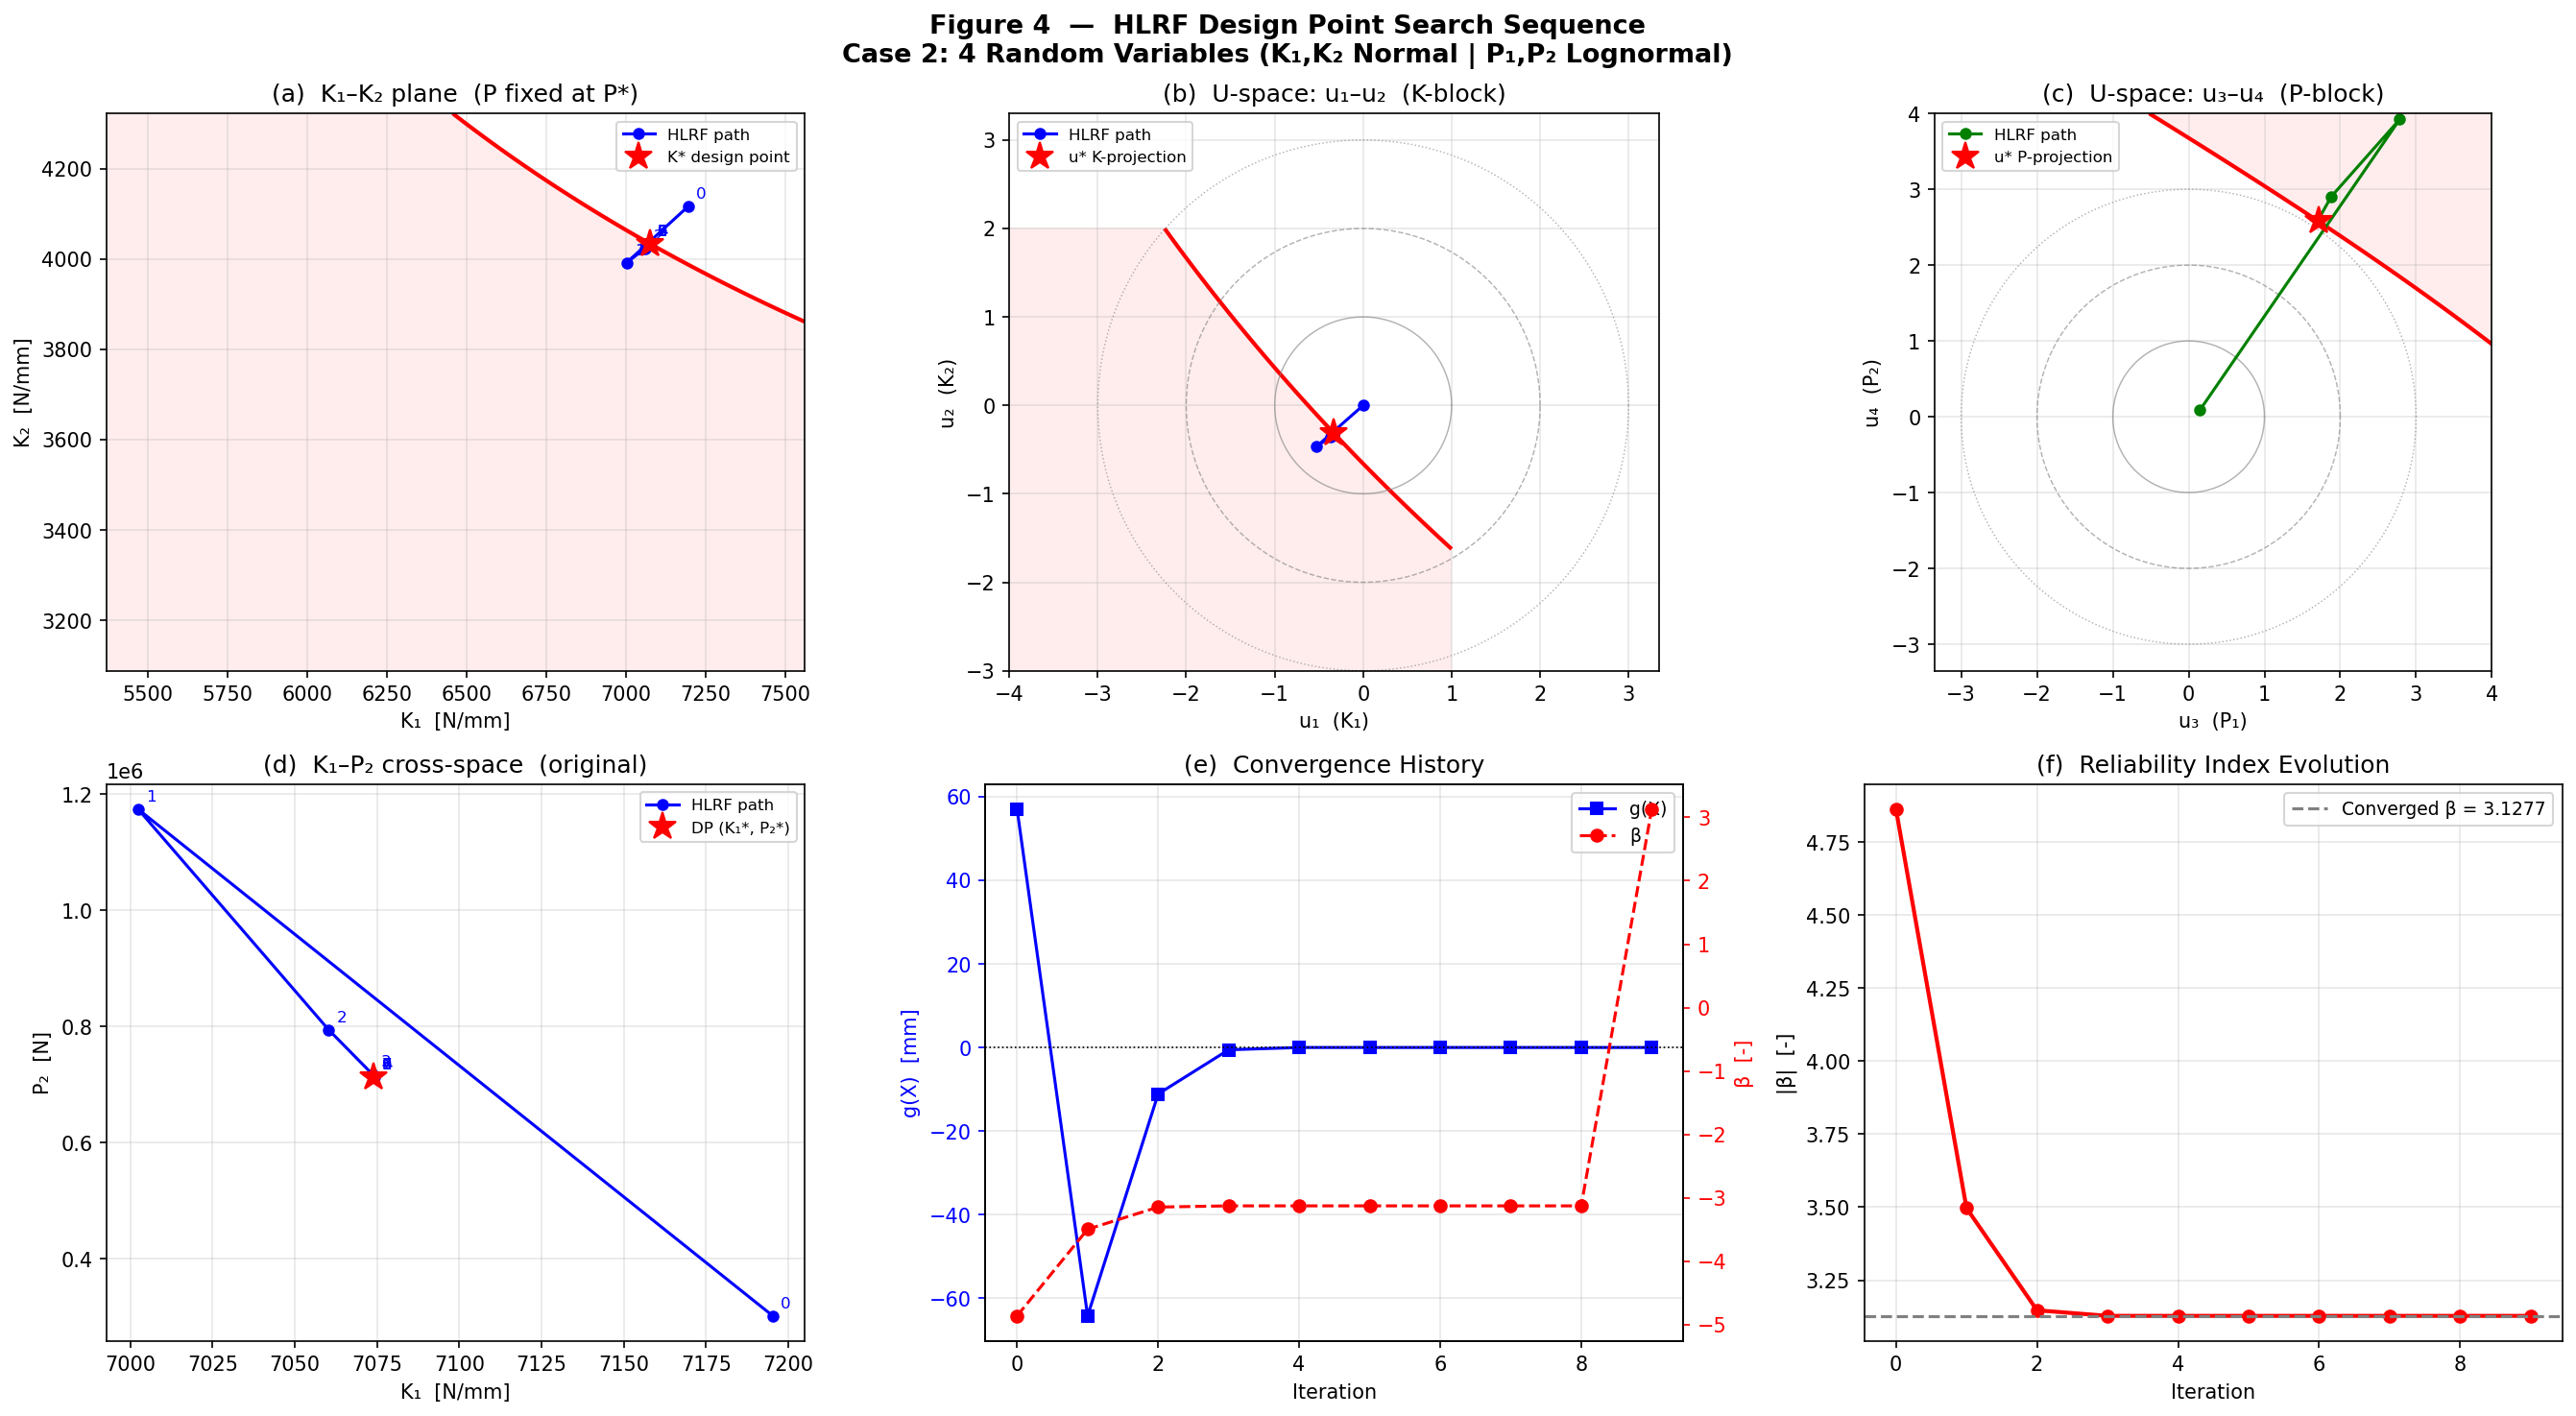

In [23]:
# Figure 4 — HLRF Design Point Search Sequence
# Case 2: 4 Random Variables
# K1, K2 ~ Normal | P1, P2 ~ Lognormal

iters  = [h['iter'] for h in history4]

K1_seq = [h['K1'] for h in history4]
K2_seq = [h['K2'] for h in history4]
P1_seq = [h['P1'] for h in history4]
P2_seq = [h['P2'] for h in history4]

u1_seq = [h['u1'] for h in history4]
u2_seq = [h['u2'] for h in history4]
u3_seq = [h['u3'] for h in history4]
u4_seq = [h['u4'] for h in history4]

g_seq  = [h['g'] for h in history4]
b_seq  = [h['β'] for h in history4]


fig = plt.figure(figsize=(18, 10))

fig.suptitle(
    "Figure 4  —  HLRF Design Point Search Sequence\n"
    "Case 2: 4 Random Variables (K₁,K₂ Normal | P₁,P₂ Lognormal)",
    fontsize=13,
    fontweight='bold'
)


# (a) K1-K2 plane in original space
# P1 and P2 are fixed at their design point values


ax1 = fig.add_subplot(2, 3, 1)


mu_K1n    = mu_K1
sigma_K1n = sigma_K1
mu_K2n    = mu_K2
sigma_K2n = sigma_K2

K1g = np.linspace(mu_K1n - 5*sigma_K1n, mu_K1n + sigma_K1n, 300)
K2g = np.linspace(mu_K2n - 5*sigma_K2n, mu_K2n + sigma_K2n, 300)

K1G, K2G = np.meshgrid(K1g, K2g)

# Limit-state slice at P1* and P2*
GG = d_max - (dp_x4[2] + dp_x4[3])/(3*K1G) - dp_x4[3]/(3*K2G)

ax1.contour(K1G, K2G, GG, levels=[0], colors='red', linewidths=2)
ax1.contourf(K1G, K2G, GG, levels=[-1e9, 0], colors=['#ffcccc'], alpha=0.35)

ax1.plot(K1_seq, K2_seq, 'b-o', ms=5, lw=1.5, label='HLRF path')

for i, (k1, k2) in enumerate(zip(K1_seq, K2_seq)):
    ax1.annotate(
        str(i),
        (k1, k2),
        textcoords='offset points',
        xytext=(4, 4),
        fontsize=8,
        color='blue'
    )

ax1.plot(dp_x4[0], dp_x4[1], 'r*', ms=14, zorder=6, label='K* design point')

ax1.set_xlabel('K₁  [N/mm]')
ax1.set_ylabel('K₂  [N/mm]')
ax1.set_title('(a)  K₁–K₂ plane  (P fixed at P*)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)


# (b) u1-u2 plane in standard normal space


ax2 = fig.add_subplot(2, 3, 2)

u1g = np.linspace(-4, 1, 200)
u2g = np.linspace(-3, 2, 200)

U1G, U2G = np.meshgrid(u1g, u2g)

GU = np.array([
    [
        g_in_u_4D(np.array([u1, u2, dp_u4[2], dp_u4[3]]))
        for u1 in u1g
    ]
    for u2 in u2g
])

ax2.contour(U1G, U2G, GU, levels=[0], colors='red', linewidths=2)
ax2.contourf(U1G, U2G, GU, levels=[-1e9, 0], colors=['#ffcccc'], alpha=0.35)

for r, ls in zip([1, 2, 3], ['-', '--', ':']):
    theta = np.linspace(0, 2*np.pi, 200)
    ax2.plot(
        r*np.cos(theta),
        r*np.sin(theta),
        'gray',
        ls=ls,
        lw=0.7,
        alpha=0.6
    )

ax2.plot(u1_seq, u2_seq, 'b-o', ms=5, lw=1.5, label='HLRF path')
ax2.plot(dp_u4[0], dp_u4[1], 'r*', ms=14, label='u* K-projection')

ax2.set_xlabel('u₁  (K₁)')
ax2.set_ylabel('u₂  (K₂)')
ax2.set_title('(b)  U-space: u₁–u₂  (K-block)')
ax2.set_aspect('equal')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)



# (c) u3-u4 plane in standard normal space
# u1 and u2 are fixed at design point values


ax3 = fig.add_subplot(2, 3, 3)

u3g = np.linspace(-1, 4, 200)
u4g = np.linspace(-1, 4, 200)

U3G, U4G = np.meshgrid(u3g, u4g)

GU2 = np.array([
    [
        g_in_u_4D(np.array([dp_u4[0], dp_u4[1], u3, u4]))
        for u3 in u3g
    ]
    for u4 in u4g
])

ax3.contour(U3G, U4G, GU2, levels=[0], colors='red', linewidths=2)
ax3.contourf(U3G, U4G, GU2, levels=[-1e9, 0], colors=['#ffcccc'], alpha=0.35)

for r, ls in zip([1, 2, 3], ['-', '--', ':']):
    theta = np.linspace(0, 2*np.pi, 200)
    ax3.plot(
        r*np.cos(theta),
        r*np.sin(theta),
        'gray',
        ls=ls,
        lw=0.7,
        alpha=0.6
    )

ax3.plot(u3_seq, u4_seq, 'g-o', ms=5, lw=1.5, label='HLRF path')
ax3.plot(dp_u4[2], dp_u4[3], 'r*', ms=14, label='u* P-projection')

ax3.set_xlabel('u₃  (P₁)')
ax3.set_ylabel('u₄  (P₂)')
ax3.set_title('(c)  U-space: u₃–u₄  (P-block)')
ax3.set_aspect('equal')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)


# (d) K1-P2 cross-plane in original space


ax4 = fig.add_subplot(2, 3, 4)

ax4.plot(K1_seq, P2_seq, 'b-o', ms=5, lw=1.5, label='HLRF path')

for i, (k1, p2v) in enumerate(zip(K1_seq, P2_seq)):
    ax4.annotate(
        str(i),
        (k1, p2v),
        textcoords='offset points',
        xytext=(4, 4),
        fontsize=8,
        color='blue'
    )

ax4.plot(dp_x4[0], dp_x4[3], 'r*', ms=14, label='DP (K₁*, P₂*)')

ax4.set_xlabel('K₁  [N/mm]')
ax4.set_ylabel('P₂  [N]')
ax4.set_title('(d)  K₁–P₂ cross-space  (original)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)



# (e) Convergence history of g and beta


ax5 = fig.add_subplot(2, 3, 5)
ax5b = ax5.twinx()

ax5.plot(iters, g_seq, 'b-s', ms=6, lw=1.5, label='g(X)')
ax5b.plot(iters, b_seq, 'r-o', ms=6, lw=1.5, linestyle='--', label='β')

ax5.axhline(0, color='k', lw=0.8, linestyle=':')

ax5.set_xlabel('Iteration')
ax5.set_ylabel('g(X)  [mm]', color='blue')
ax5b.set_ylabel('β  [-]', color='red')

ax5.set_title('(e)  Convergence History')

ax5.tick_params(axis='y', colors='blue')
ax5b.tick_params(axis='y', colors='red')

lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()

ax5.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax5.grid(True, alpha=0.3)


# (f) Reliability index evolution


ax6 = fig.add_subplot(2, 3, 6)

ax6.plot(iters, [abs(b) for b in b_seq], 'r-o', ms=6, lw=2)
ax6.axhline(
    beta4,
    color='gray',
    lw=1.5,
    linestyle='--',
    label=f'Converged β = {beta4:.4f}'
)

ax6.set_xlabel('Iteration')
ax6.set_ylabel('|β|  [-]')
ax6.set_title('(f)  Reliability Index Evolution')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)


# ============================================================
# Save figure
# ============================================================

plt.tight_layout()

plt.savefig(
    'Fig4_HLRF_probabilistic_loads.png',
    dpi=150,
    bbox_inches='tight'
)

plt.close()

print("\n  → Saved: Fig4_HLRF_probabilistic_loads.png")

display(Markdown("## Figure 4 — HLRF Design Point Search Sequence: Case 2"))

display(Image(filename='Fig4_HLRF_probabilistic_loads.png'))

<h1>Simulation methods overview</h1>

The probability of failure is

$$
P_f=P[g(\mathbf{X})\leq 0].
$$

Simulation methods estimate $(P_f)$ by generating samples of the random variables and evaluating the limit-state function.

For crude Monte Carlo simulation,

$$
\hat{P}_f^{CMC}
=
\frac{1}{N}
\sum_{i=1}^{N}
I[g(\mathbf{X}^{(i)})\leq 0],
$$

where $(I[\cdot])$ is the failure indicator function.

For importance sampling, samples are generated from a proposal density $(h(\mathbf{x}))$, and the estimator becomes

$$
\hat{P}_f^{IS}
=
\frac{1}{N}
\sum_{i=1}^{N}
I[g(\mathbf{X}^{(i)})\leq 0]
\frac{f(\mathbf{X}^{(i)})}{h(\mathbf{X}^{(i)})}.
$$

The likelihood ratio is

$$
w(\mathbf{x})
=
\frac{f(\mathbf{x})}{h(\mathbf{x})}.
$$

Importance sampling reduces variance by drawing more samples near the failure region.

<h3>Variables from Previous Sections</h1>

In [26]:
dp_u2D = dp_u
dp_x2D = dp_x
beta_2D = beta
pf_FORM_2D = pf_FORM

dp_u4D = dp_u4
dp_x4D = dp_x4
beta_4D = beta4
pf_FORM_4D = pf4

P1_nom = 2.04e5     # [N]
P2_nom = 6.12e5     # [N]
d_max  = 100.0      # [mm]

RNG = np.random.default_rng(2024)

<h3>Helper Function for Case 1</h3>

In [27]:
def u_to_x_2D(U):
    """
    Transform standard normal variables U to physical stiffness variables K.

    Input:
        U : array of shape (2,) or (2, N)

    Output:
        K : array of shape (2,) or (2, N)
    """
    return mu_K[:, None] + L_K @ U if U.ndim == 2 else mu_K + L_K @ U


def g_2D(K):
    """
    Limit state function for Case 1.

    Failure occurs when:
        g(K1, K2) <= 0

    where:
        g = d_max - roof displacement
    """
    K1 = K[0]
    K2 = K[1]

    return d_max - (P1_nom + P2_nom)/(3.0*K1) - P2_nom/(3.0*K2)


def sample_f_2D(N, rng):
    """
    Generate samples from the original distribution of K1 and K2.
    """
    U = rng.standard_normal((2, N))
    K = mu_K[:, None] + L_K @ U

    return K

<h3>Helper functions for Case 2</h3>

In [28]:
def u_to_x_4D_batch(U):
    """
    Transform U-space samples to original physical variables.

    U = [u_K1, u_K2, u_P1, u_P2]

    Output:
        X = [K1, K2, P1, P2]
    """
    K = mu_K[:, None] + L_K @ U[:2, :]

    lnP = mu_lnP[:, None] + L_lnP @ U[2:, :]
    P = np.exp(lnP)

    X = np.vstack([K, P])

    return X


def x_to_u_4D_batch(X):
    """
    Transform physical variables X = [K1, K2, P1, P2]
    back to U-space.
    """
    K = X[:2, :]
    P = X[2:, :]

    U_K = L_K_inv @ (K - mu_K[:, None])
    U_P = L_lnP_inv @ (np.log(P) - mu_lnP[:, None])

    U = np.vstack([U_K, U_P])

    return U


def g_4D_batch(X):
    """
    Limit state function for Case 2.

    X = [K1, K2, P1, P2]

    Failure occurs when:
        g(X) <= 0
    """
    K1 = X[0]
    K2 = X[1]
    P1 = X[2]
    P2 = X[3]

    return d_max - (P1 + P2)/(3.0*K1) - P2/(3.0*K2)


def sample_f_4D(N, rng):
    """
    Generate original-distribution samples for Case 2 by sampling U ~ N(0, I)
    and transforming to X.
    """
    U = rng.standard_normal((4, N))
    X = u_to_x_4D_batch(U)

    return X

<h3>Statistical Functions</h3>

In [29]:
def ci95_from_samples(values):
    """
    Compute mean, variance of mean, and 95% confidence interval
    from estimator sample values.
    """
    values = np.asarray(values)

    estimate = np.mean(values)
    variance = np.var(values, ddof=1) / len(values)
    standard_error = np.sqrt(variance)

    lower = estimate - 1.96 * standard_error
    upper = estimate + 1.96 * standard_error

    cov = standard_error / (abs(estimate) + 1e-30)

    return estimate, lower, upper, cov


def beta_from_pf(pf):
    """
    Convert probability of failure to reliability index beta.
    """
    pf_safe = np.clip(pf, 1e-15, 1.0 - 1e-15)
    return -stats.norm.ppf(pf_safe)

<h1>CRUDE MONTE CARLO SIMULATION</h1>

Crude Monte Carlo directly samples from the original probability distribution of the random variables.

The estimate is

$$
\hat{P}_f
=
\frac{N_f}{N},
$$

where \(N_f\) is the number of failed samples and \(N\) is the total number of samples.

The variance of the estimator is approximated by

$$
\text{Var}(\hat{P}_f)
=
\frac{\hat{P}_f(1-\hat{P}_f)}{N}.
$$

The coefficient of variation is

$$
\text{CoV}
=
\frac{\sqrt{\text{Var}(\hat{P}_f)}}{\hat{P}_f}.
$$

Crude Monte Carlo is simple and unbiased, but it may require a large number of samples when the failure probability is small.

In [30]:

N_MCS = 500_000


def crude_mcs(sample_func, g_func, N, rng):
    """
    Crude Monte Carlo estimator.

    Pf = number of failures / total samples
    """
    X = sample_func(N, rng)
    g_values = g_func(X)

    indicator = (g_values <= 0).astype(float)

    pf = np.mean(indicator)
    var_pf = np.var(indicator, ddof=1) / N
    se_pf = np.sqrt(var_pf)

    lower = pf - 1.96 * se_pf
    upper = pf + 1.96 * se_pf

    cov = se_pf / (pf + 1e-30)

    return pf, lower, upper, cov


pf_mcs_2D, lo_mcs_2D, hi_mcs_2D, cov_mcs_2D = crude_mcs(
    sample_f_2D,
    g_2D,
    N_MCS,
    RNG
)

pf_mcs_4D, lo_mcs_4D, hi_mcs_4D, cov_mcs_4D = crude_mcs(
    sample_f_4D,
    g_4D_batch,
    N_MCS,
    RNG
)

print("\n" + "─" * 72)
print(f"4.5 CRUDE MONTE CARLO SIMULATION  |  N = {N_MCS:,}")
print("─" * 72)

for label, pf, lo, hi, cov in [
    ("Case 1: Fixed Loads", pf_mcs_2D, lo_mcs_2D, hi_mcs_2D, cov_mcs_2D),
    ("Case 2: Random Loads", pf_mcs_4D, lo_mcs_4D, hi_mcs_4D, cov_mcs_4D)
]:
    print(f"\n{label}")
    print(f"  Pf       = {pf:.6e}")
    print(f"  95% CI   = [{lo:.6e}, {hi:.6e}]")
    print(f"  beta     = {beta_from_pf(pf):.6f}")
    print(f"  COV(Pf)  = {cov:.6f}")


────────────────────────────────────────────────────────────────────────
4.5 CRUDE MONTE CARLO SIMULATION  |  N = 500,000
────────────────────────────────────────────────────────────────────────

Case 1: Fixed Loads
  Pf       = 1.148000e-03
  95% CI   = [1.054137e-03, 1.241863e-03]
  beta     = 3.049006
  COV(Pf)  = 0.041715

Case 2: Random Loads
  Pf       = 8.840000e-04
  95% CI   = [8.016231e-04, 9.663769e-04]
  beta     = 3.126667
  COV(Pf)  = 0.047544


<h1>IMPORTANCE SAMPLING CENTERED AT DESIGN POINT</h1>

Importance sampling improves efficiency by sampling near the design point, which is the most probable failure point found by FORM.

In standard normal space, the proposal distribution can be written as

$$
h(\mathbf{u})
=
\mathcal{N}(\mathbf{u}^*,\mathbf{I}),
$$

where $\mathbf{u}^*)$ is the FORM design point.

The weight is computed as

$$
w(\mathbf{u})
=
\frac{\phi(\mathbf{u})}{h(\mathbf{u})},
$$

where $(\phi(\mathbf{u}))$ is the standard normal density.

The IS estimator is

$$
\hat{P}_f^{IS}
=
\frac{1}{N}
\sum_{i=1}^{N}
I[G(\mathbf{u}^{(i)})\leq 0]w(\mathbf{u}^{(i)}).
$$

This approach usually produces smaller confidence intervals than crude Monte Carlo.

In [31]:
N_IS = 100_000


def is_dp_centered_2D(dp_x, N, rng):
    """
    Importance Sampling for Case 1.

    Proposal:
        h(K) = Normal(K*, Sigma_K)

    Original:
        f(K) = Normal(mu_K, Sigma_K)

    Weight:
        w = f(K) / h(K)
    """
    dim = 2

    Sigma_h = Sigma_K.copy()
    L_h = np.linalg.cholesky(Sigma_h)

    Z = rng.standard_normal((dim, N))
    X = dp_x[:, None] + L_h @ Z

    g_values = g_2D(X)
    indicator = (g_values <= 0).astype(float)

    inv_Sigma = np.linalg.inv(Sigma_K)

    diff_f = X - mu_K[:, None]
    diff_h = X - dp_x[:, None]

    log_weight = (
        -0.5 * np.einsum("ij,jk,ki->i", diff_f.T, inv_Sigma, diff_f)
        +0.5 * np.einsum("ij,jk,ki->i", diff_h.T, inv_Sigma, diff_h)
    )

    weights = np.exp(np.clip(log_weight, -745, 700))

    estimator_values = indicator * weights

    pf, lower, upper, cov = ci95_from_samples(estimator_values)

    return pf, lower, upper, cov


def is_dp_centered_4D(dp_u, N, rng):
    """
    Importance Sampling for Case 2 in U-space.

    Original:
        f_U(u) = N(0, I)

    Proposal:
        h_U(u) = N(u*, I)

    Weight:
        w = f_U(u) / h_U(u)

    Correct log-weight:
        log(w) = -u* dot u + 0.5 ||u*||²
    """
    dim = 4

    Z = rng.standard_normal((dim, N))
    U = dp_u[:, None] + Z

    X = u_to_x_4D_batch(U)
    g_values = g_4D_batch(X)

    indicator = (g_values <= 0).astype(float)

    log_weight = (
        -np.einsum("i,ij->j", dp_u, U)
        + 0.5 * np.dot(dp_u, dp_u)
    )

    weights = np.exp(np.clip(log_weight, -745, 700))

    estimator_values = indicator * weights

    pf, lower, upper, cov = ci95_from_samples(estimator_values)

    return pf, lower, upper, cov


pf_is1_2D, lo_is1_2D, hi_is1_2D, cov_is1_2D = is_dp_centered_2D(
    dp_x2D,
    N_IS,
    RNG
)

pf_is1_4D, lo_is1_4D, hi_is1_4D, cov_is1_4D = is_dp_centered_4D(
    dp_u4D,
    N_IS,
    RNG
)

print("\n" + "─" * 72)
print(f"4.6 IMPORTANCE SAMPLING CENTERED AT DESIGN POINT  |  N = {N_IS:,}")
print("─" * 72)

for label, pf, lo, hi, cov in [
    ("Case 1: Fixed Loads", pf_is1_2D, lo_is1_2D, hi_is1_2D, cov_is1_2D),
    ("Case 2: Random Loads", pf_is1_4D, lo_is1_4D, hi_is1_4D, cov_is1_4D)
]:
    print(f"\n{label}")
    print(f"  Pf       = {pf:.6e}")
    print(f"  95% CI   = [{lo:.6e}, {hi:.6e}]")
    print(f"  beta     = {beta_from_pf(pf):.6f}")
    print(f"  COV(Pf)  = {cov:.6f}")


────────────────────────────────────────────────────────────────────────
4.6 IMPORTANCE SAMPLING CENTERED AT DESIGN POINT  |  N = 100,000
────────────────────────────────────────────────────────────────────────

Case 1: Fixed Loads
  Pf       = 1.063476e-03
  95% CI   = [1.051088e-03, 1.075864e-03]
  beta     = 3.071908
  COV(Pf)  = 0.005943

Case 2: Random Loads
  Pf       = 9.162156e-04
  95% CI   = [9.055310e-04, 9.269001e-04]
  beta     = 3.116127
  COV(Pf)  = 0.005950


<h1>IMPORTANCE SAMPLING WITH OPTIMISED COVARIANCE IN U-SPACE</h1>

In optimized-covariance importance sampling, the proposal distribution is still centered at the design point, but its covariance matrix is adapted:

$$
h(\mathbf{u})
=
\mathcal{N}(\mathbf{u}^*,\boldsymbol{\Sigma}_h).
$$

The covariance matrix $(\boldsymbol{\Sigma}_h)$ is estimated from pilot simulations to reduce the variance of the importance sampling estimator.

The goal is to better match the shape of the important failure region near the design point.

The estimator remains

$$
\hat{P}_f
=
\frac{1}{N}
\sum_{i=1}^{N}
I[G(\mathbf{u}^{(i)})\leq 0]
\frac{\phi(\mathbf{u}^{(i)})}{h(\mathbf{u}^{(i)})}.
$$

For this problem, optimized covariance is expected to give results close to the basic design-point IS method because the failure boundary is nearly linear near the design point.

In [32]:
N_PILOT = 10_000
N_FINAL = 100_000


def evaluate_g_from_U(U, dim):
    """
    Evaluate limit state from U-space for either Case 1 or Case 2.
    """
    if dim == 2:
        X = mu_K[:, None] + L_K @ U
        return g_2D(X)

    elif dim == 4:
        X = u_to_x_4D_batch(U)
        return g_4D_batch(X)

    else:
        raise ValueError("dim must be either 2 or 4.")


def normal_proposal_log_weight(U, mu_h, Sigma_h):
    """
    Compute log weight:
        log w = log f_U(u) - log h_U(u)

    where:
        f_U = N(0, I)
        h_U = N(mu_h, Sigma_h)
    """
    dim = U.shape[0]

    sign, logdet = np.linalg.slogdet(Sigma_h)

    if sign <= 0:
        raise ValueError("Proposal covariance matrix is not positive definite.")

    inv_Sigma_h = np.linalg.inv(Sigma_h)

    diff = U - mu_h[:, None]

    log_f = -0.5 * np.sum(U**2, axis=0)

    log_h = (
        -0.5 * np.einsum("ij,jk,ki->i", diff.T, inv_Sigma_h, diff)
        -0.5 * logdet
    )

    log_weight = log_f - log_h

    return log_weight


def is_optimised_covariance(dp_u, N_pilot, N_final, rng, dim, n_updates=6):
    """
    Importance Sampling using a normal proposal centered at the design point.

    The covariance is updated using weighted failure samples.
    """
    mu_h = dp_u.copy()
    Sigma_h = np.eye(dim)

    for update in range(n_updates):
        L_h = np.linalg.cholesky(Sigma_h + 1e-8*np.eye(dim))

        Z = rng.standard_normal((dim, N_pilot))
        U = mu_h[:, None] + L_h @ Z

        g_values = evaluate_g_from_U(U, dim)
        failure = g_values <= 0

        log_weight = normal_proposal_log_weight(U, mu_h, Sigma_h)
        weights = np.exp(np.clip(log_weight, -745, 700))

        n_fail = int(np.sum(failure))

        if n_fail > dim + 1:
            U_fail = U[:, failure]
            W_fail = weights[failure]

            W_fail = W_fail / np.sum(W_fail)

            diff_fail = U_fail - mu_h[:, None]

            Sigma_new = np.einsum("ij,j,kj->ik", diff_fail, W_fail, diff_fail)
            Sigma_new = 0.5 * (Sigma_new + Sigma_new.T)
            Sigma_new = Sigma_new + 1e-6*np.eye(dim)

            Sigma_h = Sigma_new

        else:
            break

    # Final run using optimised covariance
    L_h = np.linalg.cholesky(Sigma_h + 1e-8*np.eye(dim))

    Z = rng.standard_normal((dim, N_final))
    U = mu_h[:, None] + L_h @ Z

    g_values = evaluate_g_from_U(U, dim)
    indicator = (g_values <= 0).astype(float)

    log_weight = normal_proposal_log_weight(U, mu_h, Sigma_h)
    weights = np.exp(np.clip(log_weight, -745, 700))

    estimator_values = indicator * weights

    pf, lower, upper, cov = ci95_from_samples(estimator_values)

    return pf, lower, upper, cov, Sigma_h


pf_isopt_2D, lo_isopt_2D, hi_isopt_2D, cov_isopt_2D, Sigma_opt_2D = is_optimised_covariance(
    dp_u2D,
    N_PILOT,
    N_FINAL,
    RNG,
    dim=2
)

pf_isopt_4D, lo_isopt_4D, hi_isopt_4D, cov_isopt_4D, Sigma_opt_4D = is_optimised_covariance(
    dp_u4D,
    N_PILOT,
    N_FINAL,
    RNG,
    dim=4
)

print("\n" + "─" * 72)
print(f"4.7 IS WITH OPTIMISED COVARIANCE  |  Pilot = {N_PILOT:,}, Final = {N_FINAL:,}")
print("─" * 72)

for label, pf, lo, hi, cov, Sigma_opt in [
    ("Case 1: Fixed Loads", pf_isopt_2D, lo_isopt_2D, hi_isopt_2D, cov_isopt_2D, Sigma_opt_2D),
    ("Case 2: Random Loads", pf_isopt_4D, lo_isopt_4D, hi_isopt_4D, cov_isopt_4D, Sigma_opt_4D)
]:
    print(f"\n{label}")
    print(f"  Pf       = {pf:.6e}")
    print(f"  95% CI   = [{lo:.6e}, {hi:.6e}]")
    print(f"  beta     = {beta_from_pf(pf):.6f}")
    print(f"  COV(Pf)  = {cov:.6f}")
    print("  Optimised Sigma_h in U-space:")
    for row in Sigma_opt:
        print("    " + "  ".join(f"{value:12.6f}" for value in row))


────────────────────────────────────────────────────────────────────────
4.7 IS WITH OPTIMISED COVARIANCE  |  Pilot = 10,000, Final = 100,000
────────────────────────────────────────────────────────────────────────

Case 1: Fixed Loads
  Pf       = 1.062901e-03
  95% CI   = [1.053880e-03, 1.071921e-03]
  beta     = 3.072070
  COV(Pf)  = 0.004330
  Optimised Sigma_h in U-space:
        0.628087     -0.527690
       -0.527690      0.680977

Case 2: Random Loads
  Pf       = 9.253301e-04
  95% CI   = [9.188452e-04, 9.318150e-04]
  beta     = 3.113207
  COV(Pf)  = 0.003576
  Optimised Sigma_h in U-space:
        1.010685     -0.021171      0.027839      0.087840
       -0.021171      0.998884      0.057910      0.078885
        0.027839      0.057910      0.809982     -0.437056
        0.087840      0.078885     -0.437056      0.439182


<h1>SUMMARY TABLE</h1>

This section summarizes and compares the reliability results obtained from:

1. FORM,
2. crude Monte Carlo simulation,
3. importance sampling centered at the design point,
4. importance sampling with optimized covariance.

For each method, the following quantities are reported:

$$
\hat{P}_f,
\qquad
\hat{\beta},
\qquad
\text{CoV},
\qquad
95\%\ \text{confidence interval}.
$$

The generalized reliability index is computed from the estimated probability of failure as

$$
\hat{\beta}
=
-\Phi^{-1}(\hat{P}_f).
$$

The plots compare both the probability of failure and the reliability index for Case 1 and Case 2.

In [35]:

results = {
    "FORM": {
        "Case 1": (pf_FORM_2D, None, None, None),
        "Case 2": (pf_FORM_4D, None, None, None)
    },
    "Crude MCS": {
        "Case 1": (pf_mcs_2D, lo_mcs_2D, hi_mcs_2D, cov_mcs_2D),
        "Case 2": (pf_mcs_4D, lo_mcs_4D, hi_mcs_4D, cov_mcs_4D)
    },
    "IS DP-centered": {
        "Case 1": (pf_is1_2D, lo_is1_2D, hi_is1_2D, cov_is1_2D),
        "Case 2": (pf_is1_4D, lo_is1_4D, hi_is1_4D, cov_is1_4D)
    },
    "IS optimized covariance": {
        "Case 1": (pf_isopt_2D, lo_isopt_2D, hi_isopt_2D, cov_isopt_2D),
        "Case 2": (pf_isopt_4D, lo_isopt_4D, hi_isopt_4D, cov_isopt_4D)
    }
}

print("\n" + "=" * 72)
print("SUMMARY TABLE — ALL SIMULATION METHODS")
print("=" * 72)

for method, cases in results.items():
    print(f"\n{method}")

    for case, values in cases.items():
        pf, lo, hi, cov = values
        beta_value = beta_from_pf(pf)

        if lo is None:
            print(
                f"  {case}: "
                f"Pf = {pf:.6e}   "
                f"beta = {beta_value:.6f}"
            )
        else:
            print(
                f"  {case}: "
                f"Pf = {pf:.6e}   "
                f"CI = [{lo:.3e}, {hi:.3e}]   "
                f"beta = {beta_value:.6f}   "
                f"COV = {cov:.5f}"
            )


SUMMARY TABLE — ALL SIMULATION METHODS

FORM
  Case 1: Pf = 9.779357e-04   beta = 3.096853
  Case 2: Pf = 8.808193e-04   beta = 3.127727

Crude MCS
  Case 1: Pf = 1.148000e-03   CI = [1.054e-03, 1.242e-03]   beta = 3.049006   COV = 0.04172
  Case 2: Pf = 8.840000e-04   CI = [8.016e-04, 9.664e-04]   beta = 3.126667   COV = 0.04754

IS DP-centered
  Case 1: Pf = 1.063476e-03   CI = [1.051e-03, 1.076e-03]   beta = 3.071908   COV = 0.00594
  Case 2: Pf = 9.162156e-04   CI = [9.055e-04, 9.269e-04]   beta = 3.116127   COV = 0.00595

IS optimized covariance
  Case 1: Pf = 1.062901e-03   CI = [1.054e-03, 1.072e-03]   beta = 3.072070   COV = 0.00433
  Case 2: Pf = 9.253301e-04   CI = [9.188e-04, 9.318e-04]   beta = 3.113207   COV = 0.00358


<h1>PLOTS</h1>

Saved: Fig5_comparison_all_methods_without_adaptive.png


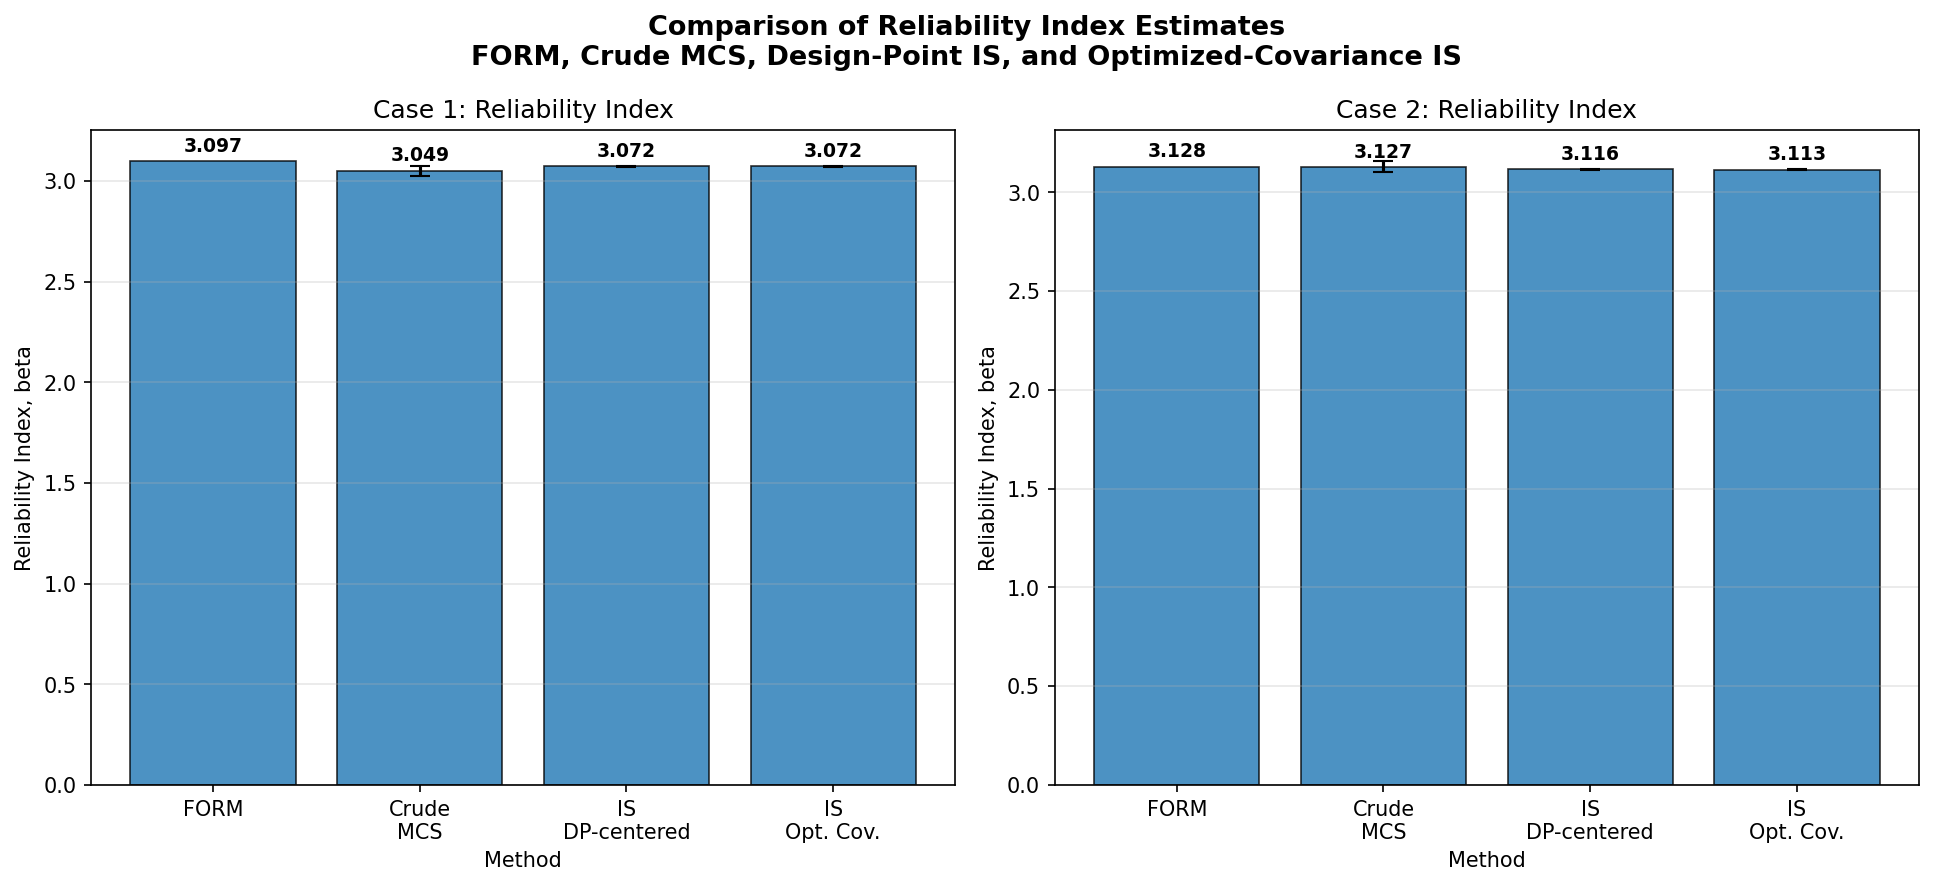

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

fig.suptitle(
    "Comparison of Reliability Index Estimates\n"
    "FORM, Crude MCS, Design-Point IS, and Optimized-Covariance IS",
    fontsize=13,
    fontweight="bold"
)

method_labels = [
    "FORM",
    "Crude\nMCS",
    "IS\nDP-centered",
    "IS\nOpt. Cov."
]

method_keys = list(results.keys())

for ax_index, case_name in enumerate(["Case 1", "Case 2"]):
    ax = axes[ax_index]

    pfs = [results[method][case_name][0] for method in method_keys]
    lows = [results[method][case_name][1] for method in method_keys]
    highs = [results[method][case_name][2] for method in method_keys]

    betas = [beta_from_pf(pf) for pf in pfs]

    bars = ax.bar(
        method_labels,
        betas,
        edgecolor="black",
        lw=0.8,
        alpha=0.8
    )

    # Confidence intervals converted from Pf-space to beta-space
    for j, (pf, lo, hi) in enumerate(zip(pfs, lows, highs)):
        if lo is not None:
            beta_lower = beta_from_pf(min(hi, 1.0 - 1e-15))
            beta_upper = beta_from_pf(max(lo, 1e-15))

            yerr_lower = max(betas[j] - beta_lower, 0.0)
            yerr_upper = max(beta_upper - betas[j], 0.0)

            ax.errorbar(
                j,
                betas[j],
                yerr=[[yerr_lower], [yerr_upper]],
                fmt="none",
                color="black",
                capsize=5,
                lw=1.5
            )

    ax.set_title(f"{case_name}: Reliability Index")
    ax.set_ylabel("Reliability Index, beta")
    ax.set_xlabel("Method")
    ax.grid(True, alpha=0.3, axis="y")

    for bar, beta_value in zip(bars, betas):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f"{beta_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()

plt.savefig(
    "Fig5_comparison_all_methods_without_adaptive.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Saved: Fig5_comparison_all_methods_without_adaptive.png")

display(Image(filename="Fig5_comparison_all_methods_without_adaptive.png"))

<h2>PLOT COMPARISON OF PROBABILITY OF FAILURE, Pf</h2>

Saved: Fig6_probability_of_failure_comparison.png


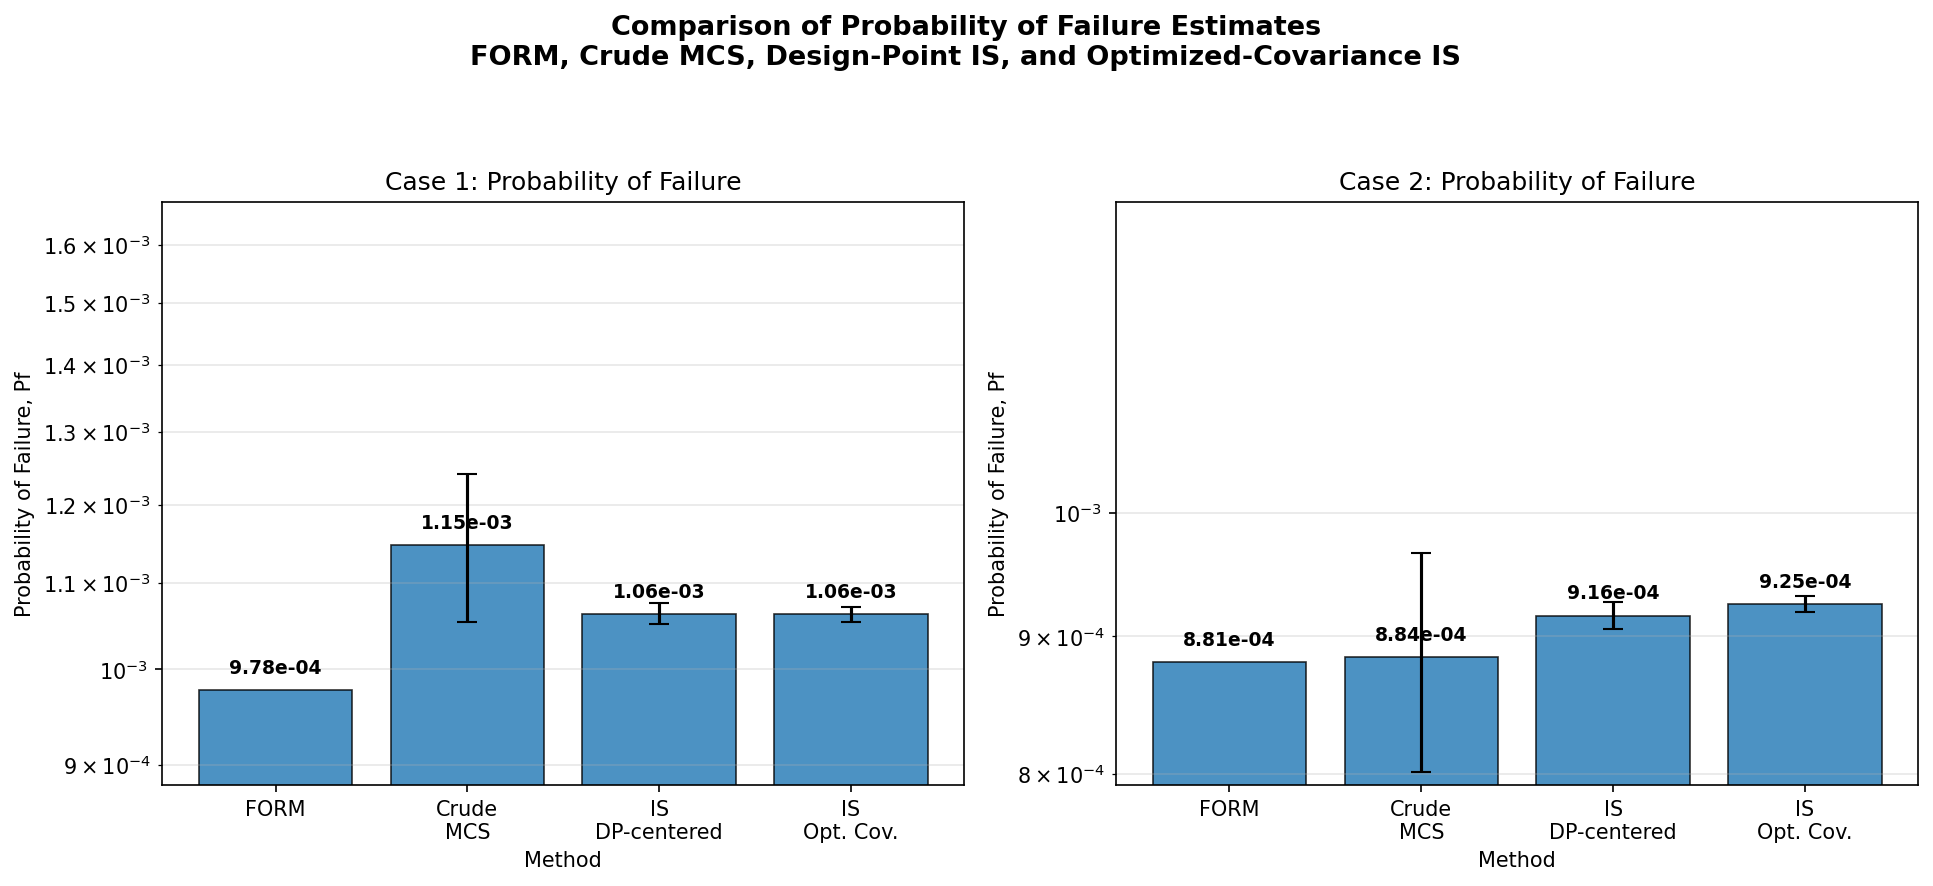

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

fig.suptitle(
    "Comparison of Probability of Failure Estimates\n"
    "FORM, Crude MCS, Design-Point IS, and Optimized-Covariance IS",
    fontsize=13,
    fontweight="bold"
)

method_labels = [
    "FORM",
    "Crude\nMCS",
    "IS\nDP-centered",
    "IS\nOpt. Cov."
]

method_keys = list(results.keys())

for ax_index, case_name in enumerate(["Case 1", "Case 2"]):
    ax = axes[ax_index]

    pfs = np.array([results[method][case_name][0] for method in method_keys])
    lows = [results[method][case_name][1] for method in method_keys]
    highs = [results[method][case_name][2] for method in method_keys]

    bars = ax.bar(
        method_labels,
        pfs,
        edgecolor="black",
        lw=0.8,
        alpha=0.8
    )

    # Add confidence intervals for simulation-based methods
    for j, (pf, lo, hi) in enumerate(zip(pfs, lows, highs)):
        if lo is not None:
            lo_plot = max(lo, 1e-15)
            hi_plot = max(hi, 1e-15)

            yerr_lower = max(pf - lo_plot, 0.0)
            yerr_upper = max(hi_plot - pf, 0.0)

            ax.errorbar(
                j,
                pf,
                yerr=[[yerr_lower], [yerr_upper]],
                fmt="none",
                color="black",
                capsize=5,
                lw=1.5
            )

    ax.set_yscale("log")
    ax.set_title(f"{case_name}: Probability of Failure")
    ax.set_ylabel("Probability of Failure, Pf")
    ax.set_xlabel("Method")
    ax.grid(True, alpha=0.3, axis="y", which="both")

    # Improve y-limits so labels fit nicely
    y_min = min([max(pf, 1e-15) for pf in pfs]) * 0.9
    y_max_candidates = []
    for pf, hi in zip(pfs, highs):
        if hi is not None:
            y_max_candidates.append(hi)
        else:
            y_max_candidates.append(pf)

    y_max = max(y_max_candidates) * 1.35
    ax.set_ylim(y_min, y_max)

    # Add value labels directly above bars using point offset
    for bar, pf_value in zip(bars, pfs):
        ax.annotate(
            f"{pf_value:.2e}",
            xy=(bar.get_x() + bar.get_width()/2, pf_value),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("Fig6_probability_of_failure_comparison.png", dpi=150, bbox_inches="tight")
plt.close()

print("Saved: Fig6_probability_of_failure_comparison.png")

display(Image(filename="Fig6_probability_of_failure_comparison.png"))